# 01 — Data Understanding

The purpose of this notebook is to understand the raw Excel workbook before cleaning, visualizing, or modelling the data.

In this first section, we only import the required tools, locate the dataset, and inspect its worksheet names.

In [3]:
from pathlib import Path

import pandas as pd

# The notebook is inside the notebooks folder, so its parent folder is the project root.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_file = project_root / "feeder_2023_2025.xlsx"

# Confirm that Python can find the dataset before trying to read it.
if not data_file.exists():
    raise FileNotFoundError(f"Dataset not found: {data_file}")

excel_file = pd.ExcelFile(data_file)

print(f"Dataset: {data_file.name}")
print(f"Worksheets: {excel_file.sheet_names}")

Dataset: feeder_2023_2025.xlsx
Worksheets: ['Hourly_Data', 'Metadata']


## Inspect the metadata sheet

Metadata is information that describes the dataset. Reading it first helps us interpret the hourly measurements correctly and avoids making unsupported assumptions.

In [4]:
metadata = pd.read_excel(excel_file, sheet_name="Metadata")
metadata

,Item,Value
0,Source PDF feeder,UNIVERSITY ROAD / 11KV PARAS
1,Source PDF Sub-station Code No,1633
2,Source PDF Meter Sr No,LT005177
3,Source PDF Class of Voltage,11KV
4,Source PDF Code no of Feeder,05505216331LO2206
5,Second feeder,11KV LAXMINAGAR (synthetic)
6,Second feeder identifiers,Synthetic placeholders because they were not p...
7,Time span,2023-01-01 to 2025-12-31
8,Interval,1 hour
9,Rows per feeder,"26,304"


## Load the hourly feeder data

We now load the main worksheet into a pandas DataFrame named `df`. A DataFrame is a table with rows and columns. Displaying the first five rows lets us inspect the structure without printing the entire dataset.

In [5]:
df = pd.read_excel(excel_file, sheet_name="Hourly_Data")

df.head()

,Date,Hour Interval,Name of Sub-station,Sub-station Code No,Feeder Name,Meter Sr No,Class of Voltage,Code no of Feeder,feeder category,feeder type,...,Frequency (Hz),Power Factor,Q1,Diff in MVArh Q1,Q2,Diff in MVArh Q2,Q3,Diff in MVArh Q3,Q4,Diff in MVArh Q4
0,2023-01-01,00:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.000421,0.980554,0.205021,0.005021,0.082869,0.002869,2.812910,0.012910,1.056455,0.006455
1,2023-01-01,01:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.016537,0.977000,0.210207,0.005186,0.085832,0.002963,2.826246,0.013336,1.063123,0.006668
2,2023-01-01,02:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.016717,0.985331,0.213910,0.003703,0.087948,0.002116,2.835768,0.009522,1.067884,0.004761
3,2023-01-01,03:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,49.994828,0.978327,0.218198,0.004289,0.090399,0.002451,2.846796,0.011028,1.073398,0.005514
4,2023-01-01,04:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.024650,0.985041,0.221605,0.003406,0.092345,0.001946,2.855555,0.008759,1.077777,0.004379


## Check the dataset dimensions

The `shape` attribute returns two numbers: `(number of rows, number of columns)`. Rows are hourly feeder observations, while columns are the recorded fields or variables.

In [6]:
rows, columns = df.shape

print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns}")

Number of rows: 52,608
Number of columns: 34


## List the column names

Column names tell us what information is available in the dataset. We print them one per line with a number so that the full list is easy to inspect.

In [7]:
for number, column_name in enumerate(df.columns, start=1):
    print(f"{number:>2}. {column_name}")

 1. Date
 2. Hour Interval
 3. Name of Sub-station
 4. Sub-station Code No
 5. Feeder Name
 6. Meter Sr No
 7. Class of Voltage
 8. Code no of Feeder
 9. feeder category
10. feeder type
11. feeder meter_no
12. Energy Import
13. Diff MWh Import
14. Energy Export
15. Diff MWh Export
16. MW(I)
17. MW(E)
18. MVA
19. Current Ir (Amp)
20. Current Iy (Amp)
21. Current Ib (Amp)
22. Voltage Vry (kV)
23. Voltage Vyb (kV)
24. Voltage Vbr (kV)
25. Frequency (Hz)
26. Power Factor
27. Q1
28. Diff in MVArh Q1
29. Q2
30. Diff in MVArh Q2
31. Q3
32. Diff in MVArh Q3
33. Q4
34. Diff in MVArh Q4


## Inspect column data types and completeness

The `info()` method summarizes every column. `Non-Null Count` shows how many rows contain a value, and `Dtype` shows how pandas interpreted the values. This is an initial completeness check; we will perform a detailed missing-value calculation later.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 52608 non-null  datetime64[us]
 1   Hour Interval        52608 non-null  str           
 2   Name of Sub-station  52608 non-null  str           
 3   Sub-station Code No  52608 non-null  str           
 4   Feeder Name          52608 non-null  str           
 5   Meter Sr No          52608 non-null  str           
 6   Class of Voltage     52608 non-null  str           
 7   Code no of Feeder    52608 non-null  str           
 8   feeder category      52608 non-null  str           
 9   feeder type          52608 non-null  str           
 10  feeder meter_no      52608 non-null  str           
 11  Energy Import        52608 non-null  float64       
 12  Diff MWh Import      52608 non-null  float64       
 13  Energy Export        52608 non-null  int64

## Count missing values

A missing value is an empty or unavailable entry. We count missing values column by column before deciding whether any imputation is necessary.

In [9]:
missing_values = df.isna().sum()
missing_values

Date                   0
Hour Interval          0
Name of Sub-station    0
Sub-station Code No    0
Feeder Name            0
Meter Sr No            0
Class of Voltage       0
Code no of Feeder      0
feeder category        0
feeder type            0
feeder meter_no        0
Energy Import          0
Diff MWh Import        0
Energy Export          0
Diff MWh Export        0
MW(I)                  0
MW(E)                  0
MVA                    0
Current Ir (Amp)       0
Current Iy (Amp)       0
Current Ib (Amp)       0
Voltage Vry (kV)       0
Voltage Vyb (kV)       0
Voltage Vbr (kV)       0
Frequency (Hz)         0
Power Factor           0
Q1                     0
Diff in MVArh Q1       0
Q2                     0
Diff in MVArh Q2       0
Q3                     0
Diff in MVArh Q3       0
Q4                     0
Diff in MVArh Q4       0
dtype: int64

## Check for exact duplicate rows

An exact duplicate occurs when all values in one row are identical to all values in another row. We count such rows before making any decision about removal.

In [10]:
exact_duplicate_count = df.duplicated().sum()

print(f"Number of exact duplicate rows: {exact_duplicate_count}")

Number of exact duplicate rows: 0


## Create a complete timestamp

The date and hour are stored separately. Forecasting requires a single chronological field, so we combine `Date` and `Hour Interval` into a new `timestamp` column. The original columns are retained.

In [11]:
date_text = df["Date"].dt.strftime("%Y-%m-%d")
time_text = df["Hour Interval"].astype(str)

df["timestamp"] = pd.to_datetime(
    date_text + " " + time_text,
    format="%Y-%m-%d %H:%M"
)

df[["Date", "Hour Interval", "timestamp"]].head()

,Date,Hour Interval,timestamp
0,2023-01-01,00:00,2023-01-01 00:00:00
1,2023-01-01,01:00,2023-01-01 01:00:00
2,2023-01-01,02:00,2023-01-01 02:00:00
3,2023-01-01,03:00,2023-01-01 03:00:00
4,2023-01-01,04:00,2023-01-01 04:00:00


## Validate the timestamp column

Before using `timestamp`, we verify its data type and count any failed conversions. A failed conversion would appear as a missing timestamp.

In [12]:
invalid_timestamp_count = df["timestamp"].isna().sum()

print(f"Timestamp data type: {df['timestamp'].dtype}")
print(f"Invalid or missing timestamps: {invalid_timestamp_count}")

Timestamp data type: datetime64[us]
Invalid or missing timestamps: 0


## Check duplicate feeder timestamps

For this dataset, a feeder and timestamp together should identify one observation. Multiple rows with the same feeder code and timestamp would create conflicting hourly readings.

In [13]:
key_columns = ["Code no of Feeder", "timestamp"]
duplicate_key_count = df.duplicated(subset=key_columns).sum()

print(f"Duplicate feeder-timestamp records: {duplicate_key_count}")

Duplicate feeder-timestamp records: 0


## Identify the feeders and count their observations

We group the rows by feeder name and feeder code, then count the number of hourly observations in each group. Keeping both fields visible helps confirm the human-readable name and its unique identifier.

In [14]:
feeder_counts = (
    df.groupby(["Feeder Name", "Code no of Feeder"])
      .size()
      .reset_index(name="observation_count")
)

feeder_counts

,Feeder Name,Code no of Feeder,observation_count
0,11KV LAXMINAGAR,SYN-LXN-11KV-01,26304
1,11KV PARAS,05505216331LO2206,26304


## Check the time coverage of each feeder

We calculate the earliest timestamp, latest timestamp, and number of distinct timestamps for each feeder. This confirms whether both feeder series cover the intended study period.

In [15]:
feeder_time_coverage = (
    df.groupby("Feeder Name")["timestamp"]
      .agg(
          first_timestamp="min",
          last_timestamp="max",
          unique_timestamps="nunique"
      )
      .reset_index()
)

feeder_time_coverage

,Feeder Name,first_timestamp,last_timestamp,unique_timestamps
0,11KV LAXMINAGAR,2023-01-01,2025-12-31 23:00:00,26304
1,11KV PARAS,2023-01-01,2025-12-31 23:00:00,26304


## Check for gaps in the hourly sequence

A complete hourly series should advance by exactly one hour between consecutive records for the same feeder. We identify any interval that is shorter or longer than one hour.

In [16]:
time_ordered = df.sort_values(["Code no of Feeder", "timestamp"]).copy()

time_ordered["time_difference"] = (
    time_ordered.groupby("Code no of Feeder")["timestamp"].diff()
)

irregular_intervals = time_ordered[
    time_ordered["time_difference"].notna()
    & time_ordered["time_difference"].ne(pd.Timedelta(hours=1))
]

print(f"Number of irregular hourly intervals: {len(irregular_intervals)}")
irregular_intervals[["Feeder Name", "timestamp", "time_difference"]].head()

Number of irregular hourly intervals: 0


,Feeder Name,timestamp,time_difference


## Verify 24 observations per feeder-day

A complete day should contain one record for each hour from 00:00 through 23:00. We count records for every combination of feeder and date, then identify any day whose count is not 24.

In [17]:
daily_observation_counts = (
    df.groupby(["Feeder Name", "Date"])
      .size()
      .reset_index(name="hourly_observation_count")
)

incomplete_days = daily_observation_counts[
    daily_observation_counts["hourly_observation_count"] != 24
]

print(f"Feeder-days checked: {len(daily_observation_counts):,}")
print(f"Feeder-days without exactly 24 observations: {len(incomplete_days)}")
incomplete_days.head()

Feeder-days checked: 2,192
Feeder-days without exactly 24 observations: 0


,Feeder Name,Date,hourly_observation_count


## Count observations by year and feeder

We extract the year from `timestamp` and count records for every year-feeder combination. This confirms how much data will eventually belong to model development and final testing.

In [18]:
df["year"] = df["timestamp"].dt.year

yearly_observation_counts = (
    df.groupby(["year", "Feeder Name"])
      .size()
      .reset_index(name="observation_count")
)

yearly_observation_counts

,year,Feeder Name,observation_count
0,2023,11KV LAXMINAGAR,8760
1,2023,11KV PARAS,8760
2,2024,11KV LAXMINAGAR,8784
3,2024,11KV PARAS,8784
4,2025,11KV LAXMINAGAR,8760
5,2025,11KV PARAS,8760


## Separate numeric and non-numeric columns

Numeric columns contain quantities on which calculations can be performed. Non-numeric columns include text, identifiers, categories, and date-time fields. This is a technical grouping based on pandas data types, not yet a decision about model usefulness.

In [19]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
non_numeric_columns = df.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}):")
for column_name in numeric_columns:
    print(f"  - {column_name}")

print(f"\nNon-numeric columns ({len(non_numeric_columns)}):")
for column_name in non_numeric_columns:
    print(f"  - {column_name}")

Numeric columns (24):
  - Energy Import
  - Diff MWh Import
  - Energy Export
  - Diff MWh Export
  - MW(I)
  - MW(E)
  - MVA
  - Current Ir (Amp)
  - Current Iy (Amp)
  - Current Ib (Amp)
  - Voltage Vry (kV)
  - Voltage Vyb (kV)
  - Voltage Vbr (kV)
  - Frequency (Hz)
  - Power Factor
  - Q1
  - Diff in MVArh Q1
  - Q2
  - Diff in MVArh Q2
  - Q3
  - Diff in MVArh Q3
  - Q4
  - Diff in MVArh Q4
  - year

Non-numeric columns (12):
  - Date
  - Hour Interval
  - Name of Sub-station
  - Sub-station Code No
  - Feeder Name
  - Meter Sr No
  - Class of Voltage
  - Code no of Feeder
  - feeder category
  - feeder type
  - feeder meter_no
  - timestamp


## Count unique values in each column

The number of unique values helps us understand a column's role. A count of 1 indicates a constant column, while a small count may indicate a category. A very large count often indicates a measurement, timestamp, or identifier.

In [20]:
unique_value_summary = (
    df.nunique(dropna=False)
      .reset_index()
      .rename(columns={"index": "column_name", 0: "unique_value_count"})
)

unique_value_summary

,column_name,unique_value_count
0,Date,1096
1,Hour Interval,24
2,Name of Sub-station,2
3,Sub-station Code No,2
4,Feeder Name,2
5,Meter Sr No,2
6,Class of Voltage,1
7,Code no of Feeder,2
8,feeder category,1
9,feeder type,1


## Identify constant columns

A constant column contains the same value in every row. It provides no variation for a machine-learning model to learn from, but we first inspect these columns and their stored values rather than dropping them immediately.

In [21]:
constant_columns = unique_value_summary.loc[
    unique_value_summary["unique_value_count"] == 1,
    "column_name"
].tolist()

constant_column_summary = pd.DataFrame({
    "column_name": constant_columns,
    "constant_value": [df[column].iloc[0] for column in constant_columns]
})

constant_column_summary

,column_name,constant_value
0,Class of Voltage,11KV
1,feeder category,URBN
2,feeder type,HT
3,Energy Export,0
4,Diff MWh Export,0
5,MW(E),0


## Inspect columns with two unique values

Several fields may describe the same two feeders using different names, codes, substations, or meter identifiers. We list their values to understand this relationship before deciding which single feeder identifier to retain for modelling.

In [22]:
two_value_columns = unique_value_summary.loc[
    unique_value_summary["unique_value_count"] == 2,
    "column_name"
].tolist()

for column_name in two_value_columns:
    values = df[column_name].drop_duplicates().tolist()
    print(f"{column_name}: {values}")

Name of Sub-station: ['UNIVERSITY ROAD', 'LAXMINAGAR']
Sub-station Code No: ['1633', 'SYN-LXN-01']
Feeder Name: ['11KV PARAS', '11KV LAXMINAGAR']
Meter Sr No: ['LT005177', 'SYN-LX005201']
Code no of Feeder: ['05505216331LO2206', 'SYN-LXN-11KV-01']
feeder meter_no: ['UR1633-FM-01', 'LX-FM-01']


## Build a feeder reference table

We select the feeder-identification fields and remove repeated combinations. If the data are consistent, the result should contain one reference row for each feeder.

In [23]:
feeder_reference_columns = [
    "Feeder Name",
    "Code no of Feeder",
    "Name of Sub-station",
    "Sub-station Code No",
    "Meter Sr No",
    "feeder meter_no"
]

feeder_reference = (
    df[feeder_reference_columns]
      .drop_duplicates()
      .sort_values("Feeder Name")
      .reset_index(drop=True)
)

feeder_reference

,Feeder Name,Code no of Feeder,Name of Sub-station,Sub-station Code No,Meter Sr No,feeder meter_no
0,11KV LAXMINAGAR,SYN-LXN-11KV-01,LAXMINAGAR,SYN-LXN-01,SYN-LX005201,LX-FM-01
1,11KV PARAS,05505216331LO2206,UNIVERSITY ROAD,1633,LT005177,UR1633-FM-01


## Define the proposed prediction target

We propose `MW(I)` as the target because it represents imported active power in megawatts—the feeder load we want to forecast. Each future prediction will correspond to one feeder and one hourly timestamp.

In [24]:
target_column = "MW(I)"

target_preview = df[["timestamp", "Feeder Name", target_column]].head(10)
target_preview

,timestamp,Feeder Name,MW(I)
0,2023-01-01 00:00:00,11KV PARAS,0.358373
1,2023-01-01 01:00:00,11KV PARAS,0.339442
2,2023-01-01 02:00:00,11KV PARAS,0.305423
3,2023-01-01 03:00:00,11KV PARAS,0.289466
4,2023-01-01 04:00:00,11KV PARAS,0.278155
5,2023-01-01 05:00:00,11KV PARAS,0.295534
6,2023-01-01 06:00:00,11KV PARAS,0.342104
7,2023-01-01 07:00:00,11KV PARAS,0.387680
8,2023-01-01 08:00:00,11KV PARAS,0.383247
9,2023-01-01 09:00:00,11KV PARAS,0.375594


## Validate the target column

A regression target must be numeric and should be checked for missing or physically invalid values. We also inspect each feeder's observed minimum and maximum load before calculating broader descriptive statistics.

In [25]:
target_missing_count = df[target_column].isna().sum()
target_negative_count = (df[target_column] < 0).sum()

print(f"Target data type: {df[target_column].dtype}")
print(f"Missing target values: {target_missing_count}")
print(f"Negative target values: {target_negative_count}")

target_range_by_feeder = (
    df.groupby("Feeder Name")[target_column]
      .agg(observation_count="count", minimum_load_mw="min", maximum_load_mw="max")
      .reset_index()
)

target_range_by_feeder

Target data type: float64
Missing target values: 0
Negative target values: 0


,Feeder Name,observation_count,minimum_load_mw,maximum_load_mw
0,11KV LAXMINAGAR,26304,0.157495,0.951021
1,11KV PARAS,26304,0.147835,1.101675


## Summarize the target by feeder

Descriptive statistics summarize the centre, spread, and range of `MW(I)`. We calculate them separately because each feeder is an independent load series with its own operating level.

In [26]:
target_statistics = (
    df.groupby("Feeder Name")[target_column]
      .describe()
      .round(4)
)

target_statistics

,count,mean,std,min,25%,50%,75%,max
Feeder Name,,,,,,,,
11KV LAXMINAGAR,26304.0,0.4420,0.1395,0.1575,0.3392,0.4082,0.5209,0.9510
11KV PARAS,26304.0,0.4941,0.1602,0.1478,0.3765,0.4565,0.5856,1.1017


## Compare relative load variability

The coefficient of variation expresses standard deviation as a percentage of the mean. This allows variability to be compared even when the feeders operate at different average load levels.

In [27]:
load_variability = (
    df.groupby("Feeder Name")[target_column]
      .agg(mean_load_mw="mean", standard_deviation_mw="std")
      .reset_index()
)

load_variability["coefficient_of_variation_percent"] = (
    load_variability["standard_deviation_mw"]
    / load_variability["mean_load_mw"]
    * 100
)

load_variability.round(2)

,Feeder Name,mean_load_mw,standard_deviation_mw,coefficient_of_variation_percent
0,11KV LAXMINAGAR,0.44,0.14,31.56
1,11KV PARAS,0.49,0.16,32.42


## Examine the target distribution shape

Skewness measures asymmetry in the load distribution. Excess kurtosis describes how strongly the distribution's tails differ from a normal distribution. These are descriptive statistics and are not automatic outlier-removal rules.

In [28]:
target_distribution_shape = (
    df.groupby("Feeder Name")[target_column]
      .agg(
          skewness="skew",
          excess_kurtosis=lambda values: values.kurt()
      )
      .reset_index()
      .round(4)
)

target_distribution_shape

,Feeder Name,skewness,excess_kurtosis
0,11KV LAXMINAGAR,0.8687,0.2692
1,11KV PARAS,0.8420,0.2696


## Visualize the load distribution

A histogram shows how frequently different load levels occur. The density curves make the distribution shape easier to compare between the two feeders.

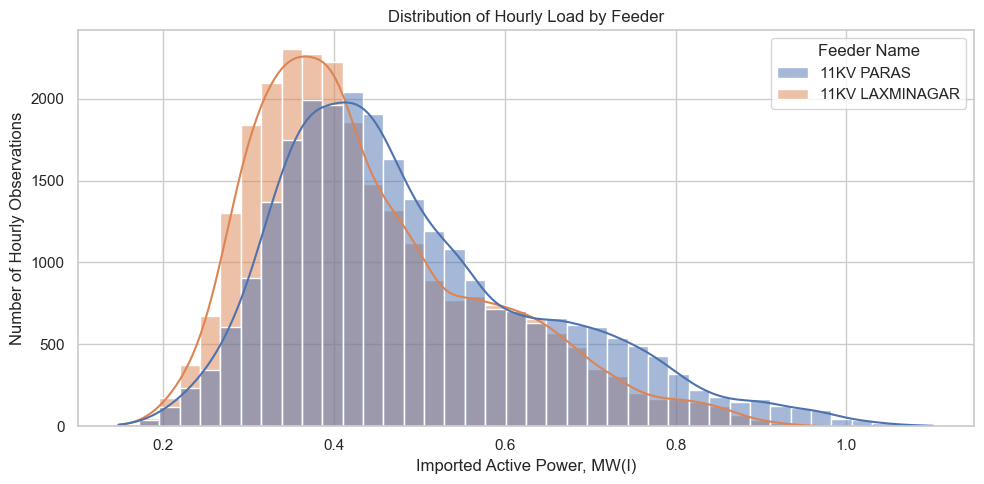

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x=target_column,
    hue="Feeder Name",
    bins=40,
    kde=True,
  
    common_norm=False
)
plt.title("Distribution of Hourly Load by Feeder")
plt.xlabel("Imported Active Power, MW(I)")
plt.ylabel("Number of Hourly Observations")
plt.tight_layout()
plt.show()

## Compare feeder load with a box plot

A box plot summarizes the median, interquartile range, and values beyond the usual 1.5 × IQR whiskers. Such points are statistical outlier candidates, not automatically incorrect readings.

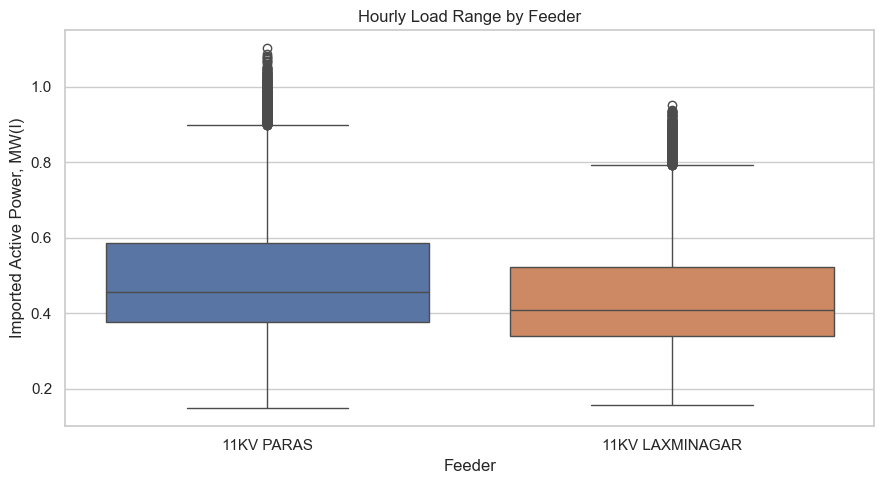

In [30]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Feeder Name",
    y=target_column,
    hue="Feeder Name",
    legend=False
)
plt.title("Hourly Load Range by Feeder")
plt.xlabel("Feeder")
plt.ylabel("Imported Active Power, MW(I)")
plt.tight_layout()
plt.show()

## Plot one week of hourly load

A one-week time-series view reveals the daily cycle and weekday-to-weekend changes without compressing all three years into an unreadable chart.

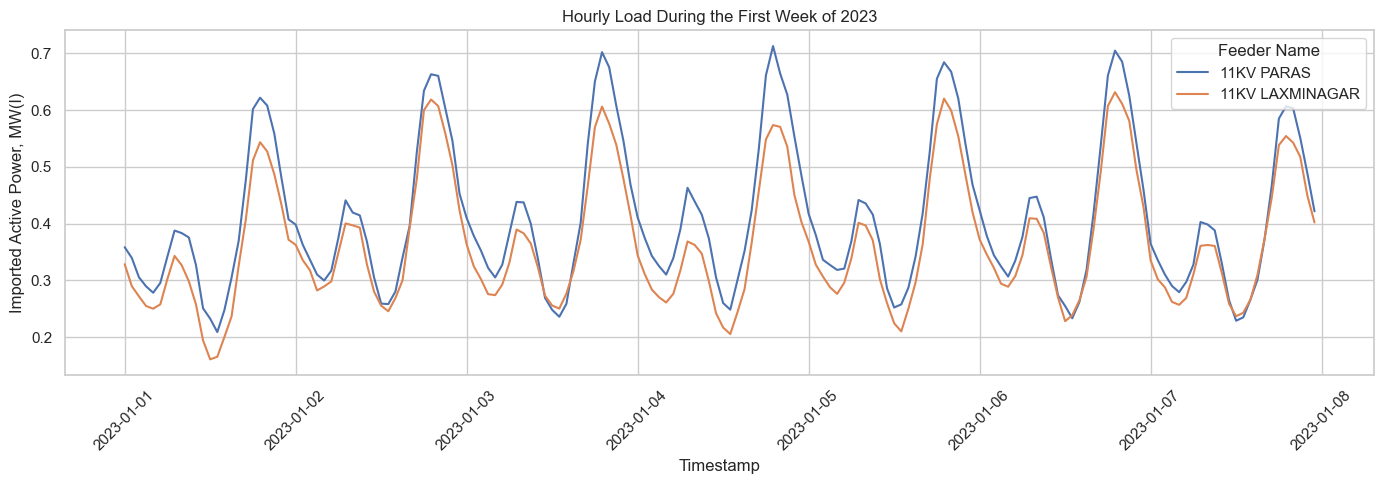

In [31]:
sample_start = df["timestamp"].min()
sample_end = sample_start + pd.Timedelta(days=7)

one_week = df[
    (df["timestamp"] >= sample_start)
    & (df["timestamp"] < sample_end)
]

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=one_week,
    x="timestamp",
    y=target_column,
    hue="Feeder Name"
)
plt.title("Hourly Load During the First Week of 2023")
plt.xlabel("Timestamp")
plt.ylabel("Imported Active Power, MW(I)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Examine the average hourly load pattern

We extract the hour of day from `timestamp`, then calculate the mean load for each feeder and hour. This reveals the typical daily demand profile.

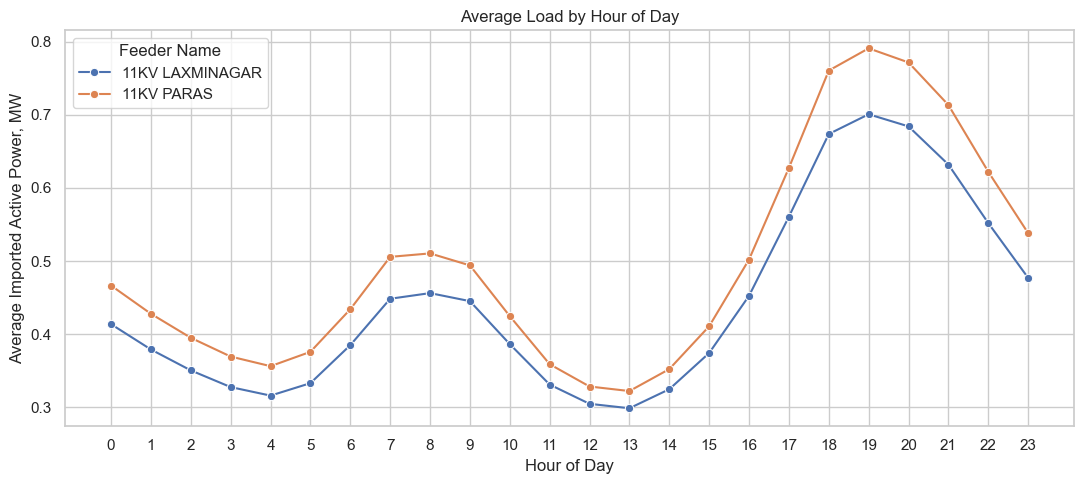

In [32]:
df["hour"] = df["timestamp"].dt.hour

average_load_by_hour = (
    df.groupby(["Feeder Name", "hour"])[target_column]
      .mean()
      .reset_index(name="average_load_mw")
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=average_load_by_hour,
    x="hour",
    y="average_load_mw",
    hue="Feeder Name",
    marker="o"
)
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Imported Active Power, MW")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Examine the average weekly load pattern

Average load by weekday helps identify differences between working days and weekends. This also tests whether weekday information is likely to be useful for forecasting.

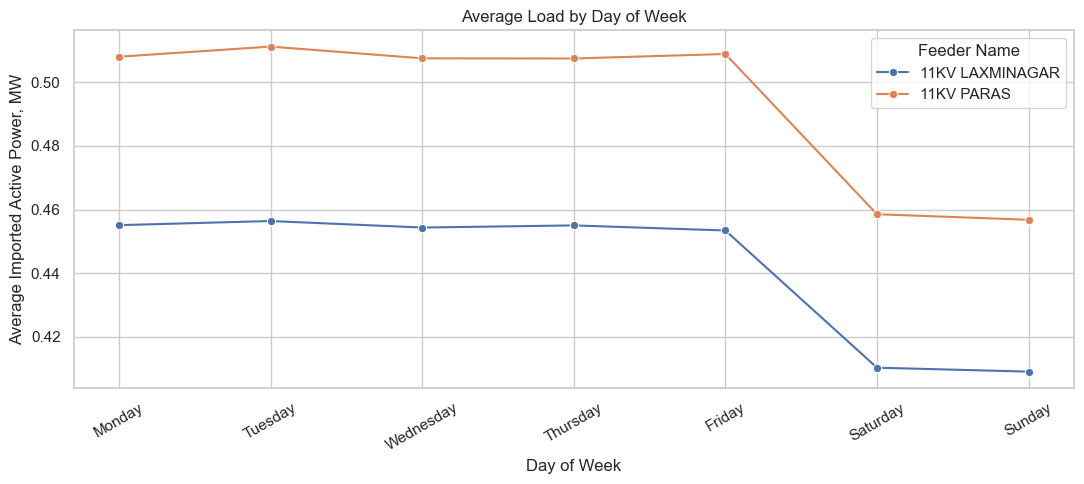

In [33]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

df["day_of_week"] = df["timestamp"].dt.day_name()
df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=weekday_order,
    ordered=True
)

average_load_by_weekday = (
    df.groupby(
        ["Feeder Name", "day_of_week"],
        observed=True
    )[target_column]
    .mean()
    .reset_index(name="average_load_mw")
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=average_load_by_weekday,
    x="day_of_week",
    y="average_load_mw",
    hue="Feeder Name",
    marker="o"
)
plt.title("Average Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Imported Active Power, MW")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Examine the average monthly load pattern

Monthly averages summarize seasonal changes across the three-year period. Month names are stored as an ordered category so the chart follows the calendar rather than alphabetical order.

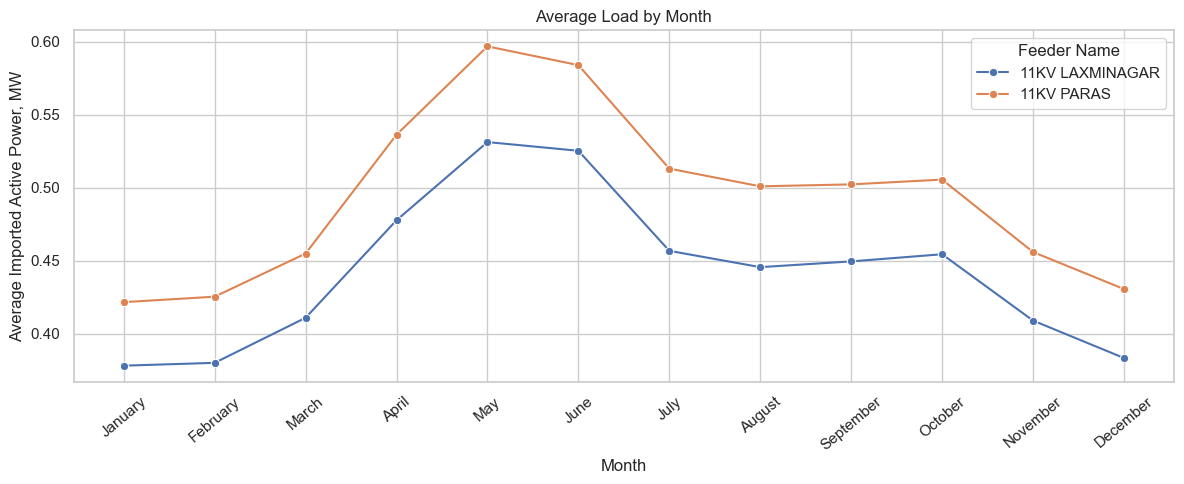

In [34]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["month_name"] = df["timestamp"].dt.month_name()
df["month_name"] = pd.Categorical(
    df["month_name"],
    categories=month_order,
    ordered=True
)

average_load_by_month = (
    df.groupby(
        ["Feeder Name", "month_name"],
        observed=True
    )[target_column]
    .mean()
    .reset_index(name="average_load_mw")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=average_load_by_month,
    x="month_name",
    y="average_load_mw",
    hue="Feeder Name",
    marker="o"
)
plt.title("Average Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Imported Active Power, MW")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

## Visualize hourly and weekly patterns together

Each heatmap cell represents the average load for one weekday-hour combination. Darker or lighter areas reveal recurring peak and low-load periods for each feeder.

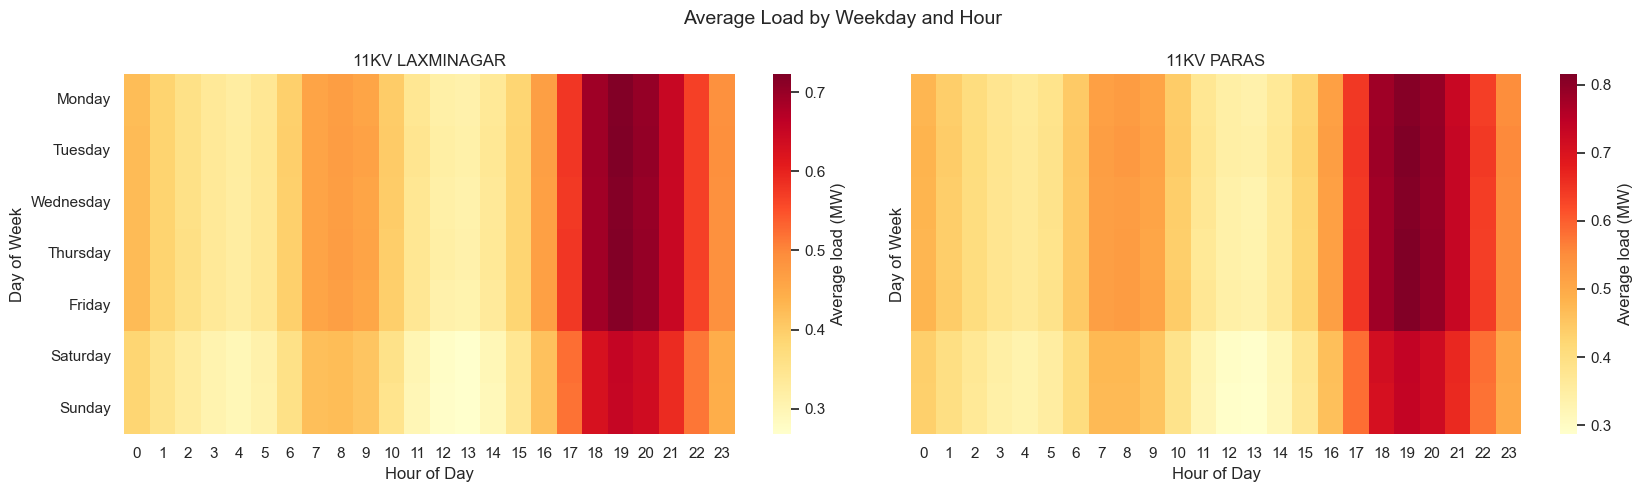

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)

for axis, feeder_name in zip(axes, sorted(df["Feeder Name"].unique())):
    feeder_data = df[df["Feeder Name"] == feeder_name]
    heatmap_data = feeder_data.pivot_table(
        index="day_of_week",
        columns="hour",
        values=target_column,
        aggfunc="mean",
        observed=True
    )

    sns.heatmap(
        heatmap_data,
        cmap="YlOrRd",
        ax=axis,
        cbar_kws={"label": "Average load (MW)"}
    )
    axis.set_title(feeder_name)
    axis.set_xlabel("Hour of Day")
    axis.set_ylabel("Day of Week")

fig.suptitle("Average Load by Weekday and Hour", fontsize=14)
plt.tight_layout()
plt.show()

## Examine correlation between numeric measurements

Pearson correlation measures the strength of a linear relationship from -1 to +1. We use a focused set of operational measurements so the heatmap remains readable. Correlation is exploratory evidence; it does not prove causation or confirm that a field is valid for day-ahead forecasting.

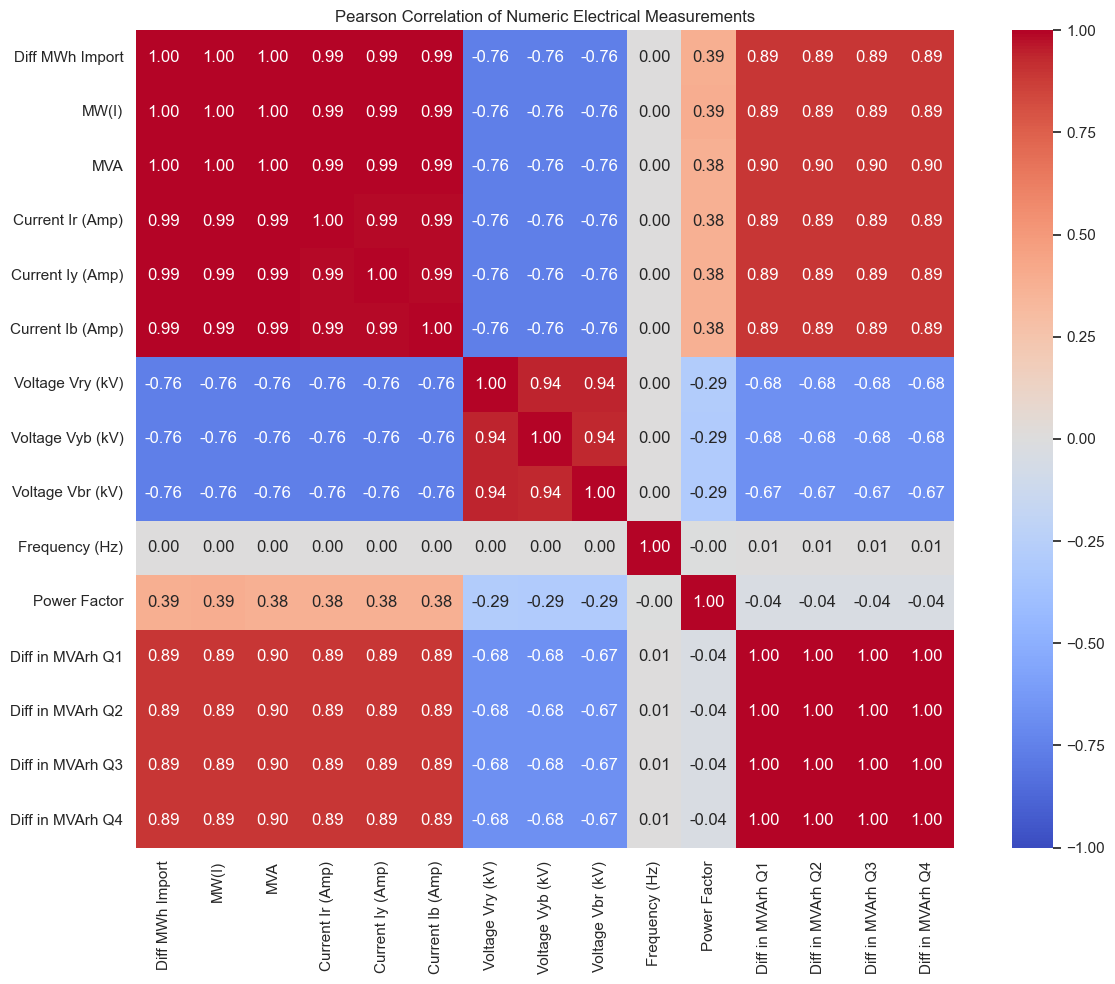

In [36]:
correlation_columns = [
    "Diff MWh Import",
    "MW(I)",
    "MVA",
    "Current Ir (Amp)",
    "Current Iy (Amp)",
    "Current Ib (Amp)",
    "Voltage Vry (kV)",
    "Voltage Vyb (kV)",
    "Voltage Vbr (kV)",
    "Frequency (Hz)",
    "Power Factor",
    "Diff in MVArh Q1",
    "Diff in MVArh Q2",
    "Diff in MVArh Q3",
    "Diff in MVArh Q4"
]

correlation_matrix = df[correlation_columns].corr(method="pearson")

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True
)
plt.title("Pearson Correlation of Numeric Electrical Measurements")
plt.tight_layout()
plt.show()

## Rank numeric relationships with the target

We extract the `MW(I)` column from the correlation matrix and rank measurements by absolute correlation. These values describe same-hour relationships only; they are not automatically selected as day-ahead predictors.

In [37]:
target_correlations = (
    correlation_matrix[target_column]
      .drop(labels=target_column)
      .rename("pearson_correlation_with_target")
      .to_frame()
)

target_correlations["absolute_correlation"] = (
    target_correlations["pearson_correlation_with_target"].abs()
)

target_correlations = (
    target_correlations
      .sort_values("absolute_correlation", ascending=False)
      .round(3)
)

target_correlations

,pearson_correlation_with_target,absolute_correlation
MVA,1.000,1.000
Diff MWh Import,1.000,1.000
Current Ir (Amp),0.994,0.994
Current Iy (Amp),0.994,0.994
Current Ib (Amp),0.994,0.994
Diff in MVArh Q3,0.892,0.892
Diff in MVArh Q4,0.892,0.892
Diff in MVArh Q1,0.892,0.892
Diff in MVArh Q2,0.892,0.892
Voltage Vyb (kV),-0.762,0.762


**Forecasting decision:** Same-hour electrical measurements are excluded from model inputs because their future values are unavailable when a day-ahead forecast is issued. Historical `MW(I)` lags and known calendar information will form the main feature set.

# Add external weather and holiday information

We add hourly temperature and relative humidity for Rajkot, plus Gujarat public holidays for 2023–2025. Weather comes from Open-Meteo's Historical Forecast API. It is a continuous historical forecast series rather than a controlled archive of forecasts issued at exactly the same 24-hour lead time, so this limitation must be stated when interpreting model performance.

In [38]:
weather_file = project_root / "external_data" / "rajkot_hourly_weather_2023_2025.csv"
holiday_file = project_root / "external_data" / "gujarat_public_holidays_2023_2025.csv"

weather = pd.read_csv(weather_file, parse_dates=["timestamp"])
holidays = pd.read_csv(holiday_file, parse_dates=["date"])

print(f"Weather rows: {len(weather):,}")
print(f"Holiday dates: {len(holidays):,}")
display(weather.head())
display(holidays.head())

Weather rows: 26,304
Holiday dates: 75


,timestamp,temperature_c,humidity_percent
0,2023-01-01 00:00:00,15.8,43
1,2023-01-01 01:00:00,14.8,47
2,2023-01-01 02:00:00,13.9,50
3,2023-01-01 03:00:00,13.2,53
4,2023-01-01 04:00:00,13.0,53


,date,holiday_name
0,2023-01-14,Uttarayan
1,2023-01-26,Republic Day
2,2023-03-08,Holi
3,2023-03-22,Cheti Chand
4,2023-03-30,Ram Navami


## Validate the external datasets

Before merging, we check time coverage, duplicates, missing values, and reasonable measurement ranges. This prevents an incorrect external-data join from silently damaging the modelling table.

In [39]:
print("Weather period:", weather["timestamp"].min(), "to", weather["timestamp"].max())
print("Duplicate weather timestamps:", weather["timestamp"].duplicated().sum())
print("Missing weather values:")
display(weather.isna().sum().to_frame("missing_count"))

invalid_temperature_count = (~weather["temperature_c"].between(-10, 55)).sum()
invalid_humidity_count = (~weather["humidity_percent"].between(0, 100)).sum()
duplicate_holiday_dates = holidays["date"].duplicated().sum()

print("Temperatures outside -10 to 55 °C:", invalid_temperature_count)
print("Humidity values outside 0 to 100%:", invalid_humidity_count)
print("Duplicate holiday dates:", duplicate_holiday_dates)

Weather period: 2023-01-01 00:00:00 to 2025-12-31 23:00:00
Duplicate weather timestamps: 0
Missing weather values:


,missing_count
timestamp,0
temperature_c,0
humidity_percent,0


Temperatures outside -10 to 55 °C: 0
Humidity values outside 0 to 100%: 0
Duplicate holiday dates: 0


## Merge weather and holiday data

Weather is joined by hourly timestamp. Because both feeders share Rajkot weather, many feeder rows match one weather row. Holidays are joined by calendar date and converted to a binary `is_holiday` feature.

In [40]:
external_columns = [
    "temperature_c", "humidity_percent", "calendar_date",
    "date", "holiday_name", "is_holiday"
]
df = df.drop(columns=external_columns, errors="ignore")

rows_before_merge = len(df)

df = df.merge(
    weather,
    on="timestamp",
    how="left",
    validate="many_to_one"
)

df["calendar_date"] = df["timestamp"].dt.normalize()
holidays["is_holiday"] = 1

df = df.merge(
    holidays,
    left_on="calendar_date",
    right_on="date",
    how="left",
    validate="many_to_one"
)

df["is_holiday"] = df["is_holiday"].fillna(0).astype(int)
df["holiday_name"] = df["holiday_name"].fillna("No holiday")
df = df.drop(columns="date")

print("Rows before merge:", f"{rows_before_merge:,}")
print("Rows after merge: ", f"{len(df):,}")

Rows before merge: 52,608
Rows after merge:  52,608


## Verify the merged features

The row count must remain unchanged, and temperature, humidity, and holiday indicators must be complete after the joins.

In [41]:
external_feature_columns = [
    "temperature_c",
    "humidity_percent",
    "is_holiday"
]

print("Missing merged feature values:")
display(df[external_feature_columns].isna().sum().to_frame("missing_count"))

print("Holiday and non-holiday hourly feeder rows:")
display(df["is_holiday"].value_counts().sort_index().rename_axis("is_holiday").to_frame("row_count"))

df[[
    "timestamp", "Feeder Name", target_column,
    "temperature_c", "humidity_percent",
    "is_holiday", "holiday_name"
]].head()

Missing merged feature values:


,missing_count
temperature_c,0
humidity_percent,0
is_holiday,0


Holiday and non-holiday hourly feeder rows:


,row_count
is_holiday,
0,49008
1,3600


,timestamp,Feeder Name,MW(I),temperature_c,humidity_percent,is_holiday,holiday_name
0,2023-01-01 00:00:00,11KV PARAS,0.358373,15.8,43,0,No holiday
1,2023-01-01 01:00:00,11KV PARAS,0.339442,14.8,47,0,No holiday
2,2023-01-01 02:00:00,11KV PARAS,0.305423,13.9,50,0,No holiday
3,2023-01-01 03:00:00,11KV PARAS,0.289466,13.2,53,0,No holiday
4,2023-01-01 04:00:00,11KV PARAS,0.278155,13.0,53,0,No holiday


## Keep 2026 future inputs separate

The files `rajkot_synthetic_weather_2026.csv` and `gujarat_public_holidays_2026.csv` are intentionally not merged into `df`. The modelling dataset ends in 2025. These 2026 inputs will be loaded only after the final model is trained, when we build the future day-ahead forecast demonstration. This separation prevents future-input information from entering training or test evaluation.

## Examine external-feature relationships with load

We examine the linear relationships of temperature and humidity with `MW(I)`, then compare average load on holidays and ordinary days. These summaries support feature evaluation but do not replace temporal model validation.

In [42]:
external_numeric_correlation = (
    df[[target_column, "temperature_c", "humidity_percent"]]
      .corr(method="pearson")[target_column]
      .drop(labels=target_column)
      .rename("correlation_with_load")
      .to_frame()
      .round(3)
)

holiday_load_summary = (
    df.groupby(["Feeder Name", "is_holiday"])[target_column]
      .agg(observation_count="count", average_load_mw="mean")
      .reset_index()
)
holiday_load_summary["day_type"] = holiday_load_summary["is_holiday"].map({
    0: "Non-holiday",
    1: "Holiday"
})

print("Weather correlation with MW(I):")
display(external_numeric_correlation)

print("Average load by holiday status:")
display(holiday_load_summary[[
    "Feeder Name", "day_type",
    "observation_count", "average_load_mw"
]].round(3))

Weather correlation with MW(I):


,correlation_with_load
temperature_c,0.171
humidity_percent,0.035


Average load by holiday status:


,Feeder Name,day_type,observation_count,average_load_mw
0,11KV LAXMINAGAR,Non-holiday,24504,0.442
1,11KV LAXMINAGAR,Holiday,1800,0.448
2,11KV PARAS,Non-holiday,24504,0.494
3,11KV PARAS,Holiday,1800,0.500


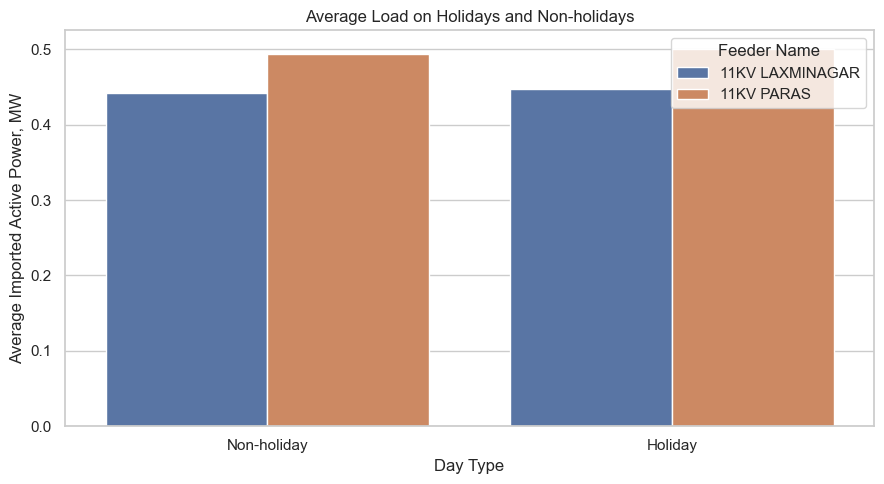

In [43]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=holiday_load_summary,
    x="day_type",
    y="average_load_mw",
    hue="Feeder Name"
)
plt.title("Average Load on Holidays and Non-holidays")
plt.xlabel("Day Type")
plt.ylabel("Average Imported Active Power, MW")
plt.tight_layout()
plt.show()

# Model feature engineering

We now construct the leakage-safe variables intended for model training. Calendar features are known in advance for every future forecast timestamp.

## Create numeric calendar features

Month and weekday names were useful for charts, but models require consistent numeric inputs. Monday is represented by 0 and Sunday by 6. The weekend indicator equals 1 for Saturday and Sunday.

In [44]:
df["month"] = df["timestamp"].dt.month
df["day_of_week_number"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week_number"] >= 5).astype(int)

calendar_feature_columns = [
    "timestamp",
    "hour",
    "day_of_week_number",
    "month",
    "is_weekend",
    "is_holiday"
]

df[calendar_feature_columns].head()

,timestamp,hour,day_of_week_number,month,is_weekend,is_holiday
0,2023-01-01 00:00:00,0,6,1,1,0
1,2023-01-01 01:00:00,1,6,1,1,0
2,2023-01-01 02:00:00,2,6,1,1,0
3,2023-01-01 03:00:00,3,6,1,1,0
4,2023-01-01 04:00:00,4,6,1,1,0


In [45]:
print("Month values:", sorted(df["month"].unique()))
print("Day-of-week values:", sorted(df["day_of_week_number"].unique()))
print("Weekend values:", sorted(df["is_weekend"].unique()))

Month values: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Day-of-week values: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Weekend values: [np.int64(0), np.int64(1)]


## Create cyclical calendar features

Calendar variables repeat in cycles. Sine and cosine encoding places the beginning and end of each cycle close together—for example, hour 23 is close to hour 0, and December is close to January.

In [46]:
import numpy as np

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week_number"] / 7
)
df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week_number"] / 7
)

df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

cyclical_feature_columns = [
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos"
]

df[["timestamp"] + cyclical_feature_columns].head()

,timestamp,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2023-01-01 00:00:00,0.000000,1.000000,-0.781831,0.62349,0.0,1.0
1,2023-01-01 01:00:00,0.258819,0.965926,-0.781831,0.62349,0.0,1.0
2,2023-01-01 02:00:00,0.500000,0.866025,-0.781831,0.62349,0.0,1.0
3,2023-01-01 03:00:00,0.707107,0.707107,-0.781831,0.62349,0.0,1.0
4,2023-01-01 04:00:00,0.866025,0.500000,-0.781831,0.62349,0.0,1.0


## Create historical load-lag features

Lag features provide earlier values of the prediction target. They must be calculated separately for each feeder and only after sorting records chronologically. For a day-ahead forecast, lags of 24 hours or longer are available when the forecast is issued.

In [47]:
df = (
    df.sort_values(["Code no of Feeder", "timestamp"])
      .reset_index(drop=True)
)

load_by_feeder = df.groupby("Code no of Feeder")[target_column]

df["load_lag_24"] = load_by_feeder.shift(24)
df["load_lag_48"] = load_by_feeder.shift(48)
df["load_lag_168"] = load_by_feeder.shift(168)

lag_feature_columns = ["load_lag_24", "load_lag_48", "load_lag_168"]

df[[
    "timestamp", "Feeder Name", target_column
] + lag_feature_columns].head(170)

,timestamp,Feeder Name,MW(I),load_lag_24,load_lag_48,load_lag_168
0,2023-01-01 00:00:00,11KV PARAS,0.358373,NaN,NaN,NaN
1,2023-01-01 01:00:00,11KV PARAS,0.339442,NaN,NaN,NaN
2,2023-01-01 02:00:00,11KV PARAS,0.305423,NaN,NaN,NaN
3,2023-01-01 03:00:00,11KV PARAS,0.289466,NaN,NaN,NaN
4,2023-01-01 04:00:00,11KV PARAS,0.278155,NaN,NaN,NaN
...,...,...,...,...,...,...
165,2023-01-07 21:00:00,11KV PARAS,0.550870,0.625266,0.620199,NaN
166,2023-01-07 22:00:00,11KV PARAS,0.488373,0.542450,0.541107,NaN
167,2023-01-07 23:00:00,11KV PARAS,0.421581,0.459129,0.468461,NaN
168,2023-01-08 00:00:00,11KV PARAS,0.351049,0.364298,0.423711,0.358373


In [48]:
lag_missing_summary = (
    df.groupby("Feeder Name")[lag_feature_columns]
      .agg(lambda values: values.isna().sum())
)

lag_missing_summary

,load_lag_24,load_lag_48,load_lag_168
Feeder Name,,,
11KV LAXMINAGAR,24,48,168
11KV PARAS,24,48,168


## Create leakage-safe rolling load features

Rolling statistics summarize recent load behaviour. We shift the load by 24 hours before applying each rolling window, ensuring that every value used would already be known when a complete day-ahead forecast is issued.

In [49]:
df["rolling_mean_24"] = (
    df.groupby("Code no of Feeder")[target_column]
      .transform(
          lambda values: values.shift(24).rolling(
              window=24, min_periods=24
          ).mean()
      )
)

df["rolling_std_24"] = (
    df.groupby("Code no of Feeder")[target_column]
      .transform(
          lambda values: values.shift(24).rolling(
              window=24, min_periods=24
          ).std()
      )
)

df["rolling_mean_168"] = (
    df.groupby("Code no of Feeder")[target_column]
      .transform(
          lambda values: values.shift(24).rolling(
              window=168, min_periods=168
          ).mean()
      )
)

rolling_feature_columns = [
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168"
]

df[[
    "timestamp", "Feeder Name", target_column
] + rolling_feature_columns].head(195)

,timestamp,Feeder Name,MW(I),rolling_mean_24,rolling_std_24,rolling_mean_168
0,2023-01-01 00:00:00,11KV PARAS,0.358373,NaN,NaN,NaN
1,2023-01-01 01:00:00,11KV PARAS,0.339442,NaN,NaN,NaN
2,2023-01-01 02:00:00,11KV PARAS,0.305423,NaN,NaN,NaN
3,2023-01-01 03:00:00,11KV PARAS,0.289466,NaN,NaN,NaN
4,2023-01-01 04:00:00,11KV PARAS,0.278155,NaN,NaN,NaN
...,...,...,...,...,...,...
190,2023-01-08 22:00:00,11KV PARAS,0.479557,0.381334,0.116583,NaN
191,2023-01-08 23:00:00,11KV PARAS,0.420394,0.379770,0.115743,0.408929
192,2023-01-09 00:00:00,11KV PARAS,0.398303,0.379218,0.115851,0.408886
193,2023-01-09 01:00:00,11KV PARAS,0.374554,0.378738,0.116063,0.408794


In [50]:
rolling_missing_summary = (
    df.groupby("Feeder Name")[rolling_feature_columns]
      .agg(lambda values: values.isna().sum())
)

rolling_missing_summary

,rolling_mean_24,rolling_std_24,rolling_mean_168
Feeder Name,,,
11KV LAXMINAGAR,47,47,191
11KV PARAS,47,47,191


## Encode feeder identity and define candidate features

The model needs to distinguish the two feeder series. Because there are only two categories, a binary encoding is sufficient. The assigned numbers are labels only and do not imply that one feeder is larger or better than the other.

In [51]:
feeder_mapping = {
    "11KV PARAS": 0,
    "11KV LAXMINAGAR": 1,
}

df["feeder_id"] = df["Feeder Name"].map(feeder_mapping)

if df["feeder_id"].isna().any():
    unknown_feeders = df.loc[
        df["feeder_id"].isna(), "Feeder Name"
    ].unique()
    raise ValueError(f"Unmapped feeder names: {unknown_feeders}")

df[["Feeder Name", "feeder_id"]].drop_duplicates()

,Feeder Name,feeder_id
0,11KV PARAS,0
26304,11KV LAXMINAGAR,1


The candidate list contains only information available before the forecast target: feeder identity, known calendar and holiday information, forecast weather, and historical load features.

In [52]:
candidate_feature_columns = [
    # Feeder identity
    "feeder_id",

    # Numeric calendar features
    "hour",
    "day_of_week_number",
    "month",
    "is_weekend",
    "is_holiday",

    # Cyclical calendar features
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",

    # External features
    "temperature_c",
    "humidity_percent",

    # Historical load features
    "load_lag_24",
    "load_lag_48",
    "load_lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
]

print(f"Number of candidate features: {len(candidate_feature_columns)}")
for feature_name in candidate_feature_columns:
    print(f"  - {feature_name}")

Number of candidate features: 20
  - feeder_id
  - hour
  - day_of_week_number
  - month
  - is_weekend
  - is_holiday
  - hour_sin
  - hour_cos
  - day_of_week_sin
  - day_of_week_cos
  - month_sin
  - month_cos
  - temperature_c
  - humidity_percent
  - load_lag_24
  - load_lag_48
  - load_lag_168
  - rolling_mean_24
  - rolling_std_24
  - rolling_mean_168


In [53]:
candidate_missing_summary = (
    df[candidate_feature_columns]
      .isna()
      .sum()
      .loc[lambda counts: counts > 0]
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

candidate_missing_summary

,missing_count
rolling_mean_168,382
load_lag_168,336
load_lag_48,96
rolling_mean_24,94
rolling_std_24,94
load_lag_24,48


## Create the model-ready dataset

The initial lag and rolling-feature gaps are mathematically unavoidable and should not be imputed. We create a separate modelling table containing identifiers, target, and candidate features, then remove only rows lacking required model values.

In [54]:
model_columns = [
    "timestamp",
    "Feeder Name",
    target_column,
] + candidate_feature_columns

model_data = (
    df[model_columns]
      .dropna(subset=candidate_feature_columns + [target_column])
      .copy()
)

print(f"Rows before removing initial history gaps: {len(df):,}")
print(f"Model-ready rows: {len(model_data):,}")
print(f"Rows removed: {len(df) - len(model_data):,}")

Rows before removing initial history gaps: 52,608
Model-ready rows: 52,226
Rows removed: 382


In [55]:
model_data_coverage = (
    model_data.groupby("Feeder Name")
      .agg(
          first_model_timestamp=("timestamp", "min"),
          last_model_timestamp=("timestamp", "max"),
          model_observations=("timestamp", "count"),
      )
      .reset_index()
)

model_data_coverage

,Feeder Name,first_model_timestamp,last_model_timestamp,model_observations
0,11KV LAXMINAGAR,2023-01-08 23:00:00,2025-12-31 23:00:00,26113
1,11KV PARAS,2023-01-08 23:00:00,2025-12-31 23:00:00,26113


In [56]:
remaining_missing_values = model_data[
    candidate_feature_columns + [target_column]
].isna().sum().sum()

print(f"Remaining missing model values: {remaining_missing_values}")
model_data.head()

Remaining missing model values: 0


,timestamp,Feeder Name,MW(I),feeder_id,hour,day_of_week_number,month,is_weekend,is_holiday,hour_sin,...,month_sin,month_cos,temperature_c,humidity_percent,load_lag_24,load_lag_48,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
191,2023-01-08 23:00:00,11KV PARAS,0.420394,0,23,6,1,1,0,-0.258819,...,0.0,1.0,21.1,58,0.421581,0.459129,0.407270,0.379770,0.115743,0.408929
192,2023-01-09 00:00:00,11KV PARAS,0.398303,0,0,0,1,0,0,0.000000,...,0.0,1.0,20.9,58,0.351049,0.364298,0.398144,0.379218,0.115851,0.408886
193,2023-01-09 01:00:00,11KV PARAS,0.374554,0,1,0,1,0,0,0.258819,...,0.0,1.0,20.0,61,0.324103,0.335627,0.362567,0.378738,0.116063,0.408794
194,2023-01-09 02:00:00,11KV PARAS,0.332975,0,2,0,1,0,0,0.500000,...,0.0,1.0,19.5,63,0.303742,0.310305,0.336351,0.378464,0.116239,0.408784
195,2023-01-09 03:00:00,11KV PARAS,0.321317,0,3,0,1,0,0,0.707107,...,0.0,1.0,17.9,71,0.279819,0.290073,0.310235,0.378037,0.116597,0.408727


# Candidate feature review

We now apply correlation analysis to the leakage-safe modelling features. This helps identify redundant predictors and shows their linear relationships with the target. Tree models can still use correlated variables, so correlation is treated as evidence for review rather than an automatic removal rule.

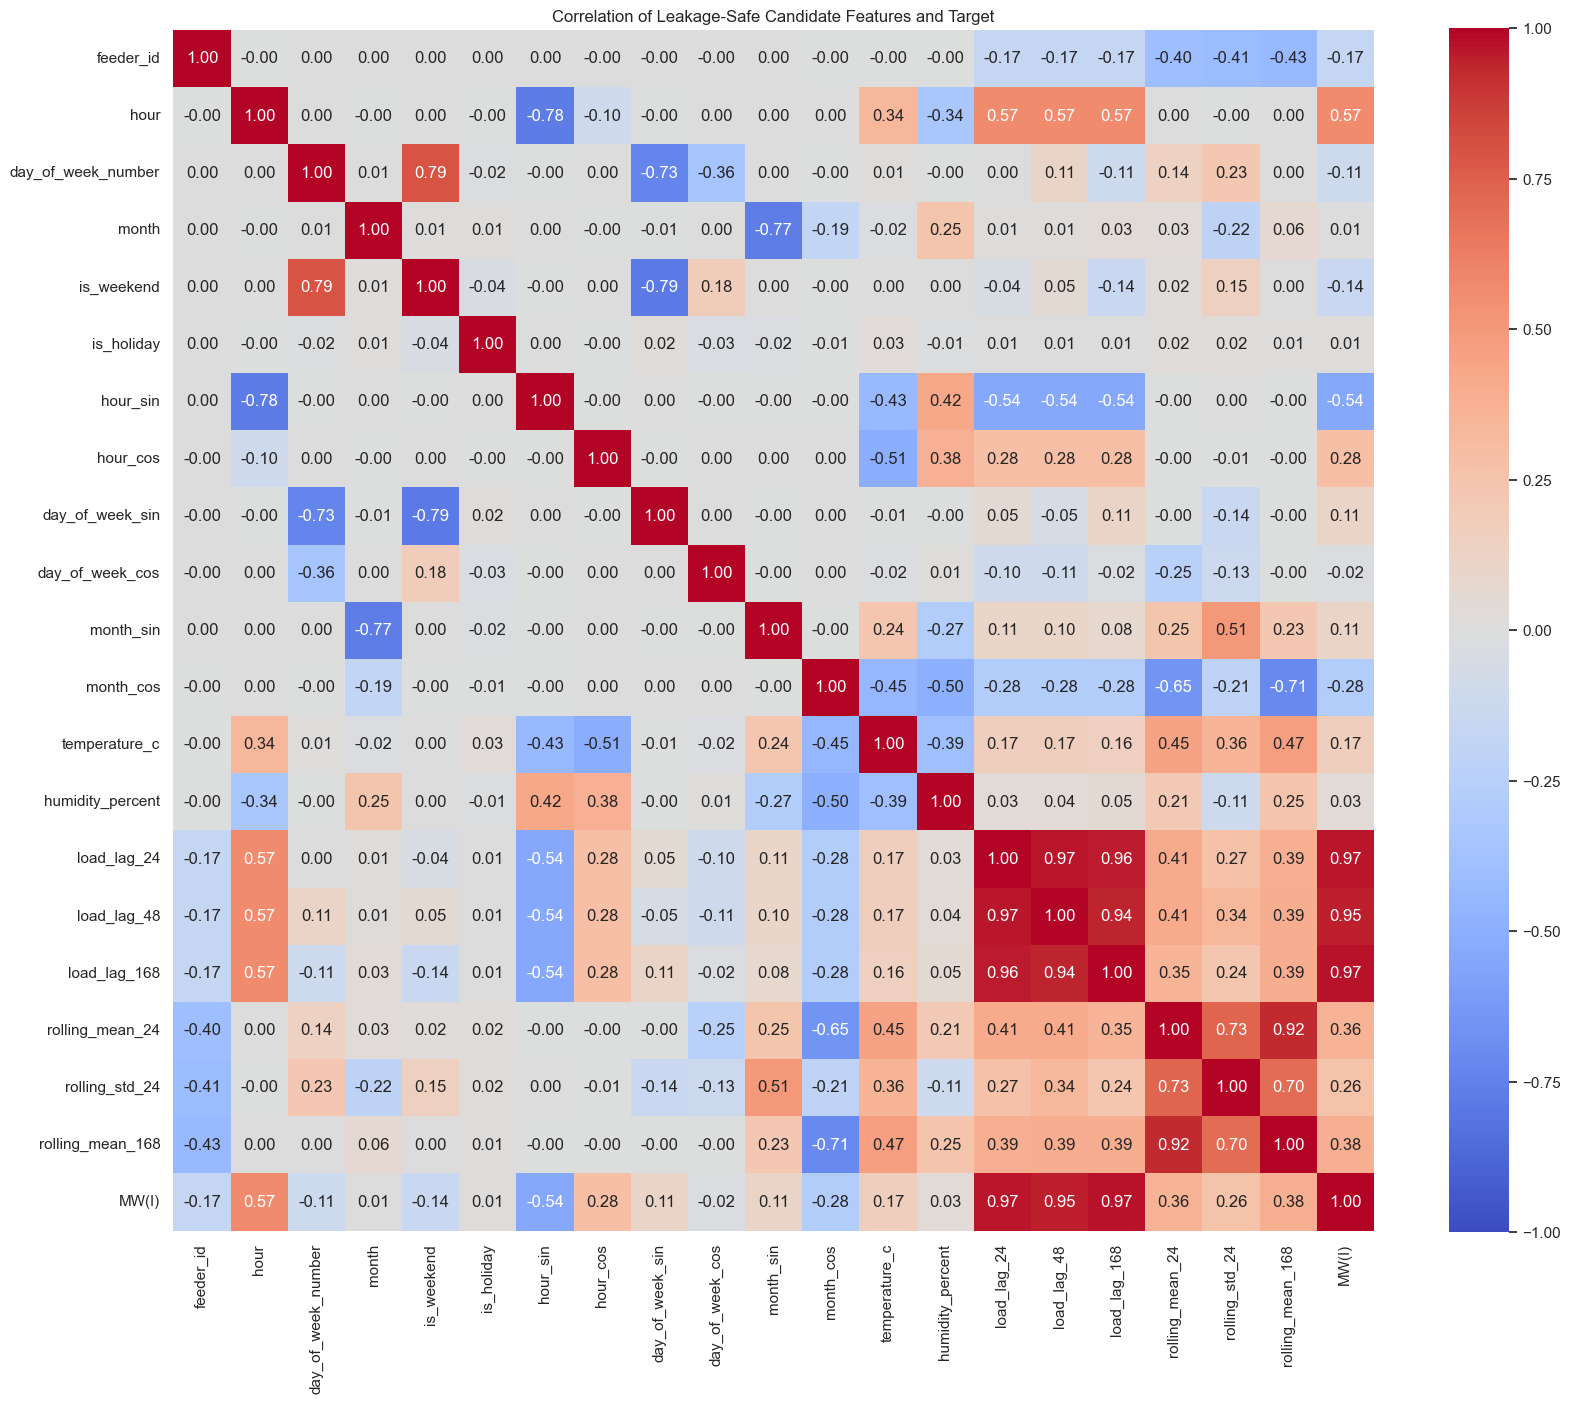

In [57]:
model_correlation_columns = candidate_feature_columns + [target_column]
model_correlation_matrix = model_data[model_correlation_columns].corr(
    method="pearson"
)

plt.figure(figsize=(17, 14))
sns.heatmap(
    model_correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True
)
plt.title("Correlation of Leakage-Safe Candidate Features and Target")
plt.tight_layout()
plt.show()

## List highly correlated candidate-feature pairs

We inspect only one half of the symmetric correlation matrix so that each pair appears once. A threshold of 0.90 flags strong redundancy for review.

In [58]:
feature_only_correlation = model_correlation_matrix.loc[
    candidate_feature_columns, candidate_feature_columns
]

upper_triangle_mask = np.triu(
    np.ones(feature_only_correlation.shape, dtype=bool),
    k=1
)

high_correlation_pairs = (
    feature_only_correlation
      .where(upper_triangle_mask)
      .stack()
      .rename("correlation")
      .reset_index()
      .rename(columns={
          "level_0": "feature_1",
          "level_1": "feature_2",
      })
)

high_correlation_pairs["absolute_correlation"] = (
    high_correlation_pairs["correlation"].abs()
)

high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs["absolute_correlation"] >= 0.90
    ]
    .sort_values("absolute_correlation", ascending=False)
    .reset_index(drop=True)
    .round(3)
)

high_correlation_pairs

,feature_1,feature_2,correlation,absolute_correlation
0,load_lag_24,load_lag_48,0.965,0.965
1,load_lag_24,load_lag_168,0.959,0.959
2,load_lag_48,load_lag_168,0.945,0.945
3,rolling_mean_24,rolling_mean_168,0.924,0.924


**Selection rule:** Highly correlated features are retained initially for Random Forest and XGBoost. After temporal validation, model-based importance and performance comparisons will determine whether removing redundant variables improves generalization or interpretability.

# Chronological data splitting

Time-series data must be split by date rather than randomly. Random shuffling would allow the model to train on later observations and evaluate on earlier ones, producing an unrealistic estimate of forecasting performance.

## Separate development data and final test data

The development period covers 2023–2024 and will be used for training, validation, feature decisions, and hyperparameter tuning. The complete 2025 period is reserved for one final comparison after all modelling decisions are fixed.

In [59]:
test_start = pd.Timestamp("2025-01-01 00:00:00")

development_data = (
    model_data[model_data["timestamp"] < test_start]
      .sort_values(["timestamp", "Feeder Name"])
      .reset_index(drop=True)
)

test_data = (
    model_data[model_data["timestamp"] >= test_start]
      .sort_values(["timestamp", "Feeder Name"])
      .reset_index(drop=True)
)

print(f"Development rows: {len(development_data):,}")
print(f"Final test rows:  {len(test_data):,}")

Development rows: 34,706
Final test rows:  17,520


In [60]:
split_summary = pd.DataFrame({
    "dataset": ["Development", "Final test"],
    "first_timestamp": [
        development_data["timestamp"].min(),
        test_data["timestamp"].min(),
    ],
    "last_timestamp": [
        development_data["timestamp"].max(),
        test_data["timestamp"].max(),
    ],
    "row_count": [len(development_data), len(test_data)],
})

split_summary

,dataset,first_timestamp,last_timestamp,row_count
0,Development,2023-01-08 23:00:00,2024-12-31 23:00:00,34706
1,Final test,2025-01-01 00:00:00,2025-12-31 23:00:00,17520


## Create feature and target matrices

`X` contains predictor features and `y` contains the load target. The 2025 matrices are prepared now but must not be used for tuning or selecting models.

In [61]:
X_development = development_data[candidate_feature_columns].copy()
y_development = development_data[target_column].copy()

X_test = test_data[candidate_feature_columns].copy()
y_test = test_data[target_column].copy()

print("X_development shape:", X_development.shape)
print("y_development shape:", y_development.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_development shape: (34706, 20)
y_development shape: (34706,)
X_test shape: (17520, 20)
y_test shape: (17520,)


## Create chronological training and validation sets

The earlier part of `development_data` is used to fit initial models. The later six months of 2024 form a validation period for comparing features, models, and hyperparameters without examining the 2025 test results.

In [62]:
validation_start = pd.Timestamp("2024-07-01 00:00:00")

training_data = (
    development_data[development_data["timestamp"] < validation_start]
      .copy()
)

validation_data = (
    development_data[development_data["timestamp"] >= validation_start]
      .copy()
)

print(f"Training rows:   {len(training_data):,}")
print(f"Validation rows: {len(validation_data):,}")

Training rows:   25,874
Validation rows: 8,832


In [63]:
training_validation_summary = pd.DataFrame({
    "dataset": ["Training", "Validation"],
    "first_timestamp": [
        training_data["timestamp"].min(),
        validation_data["timestamp"].min(),
    ],
    "last_timestamp": [
        training_data["timestamp"].max(),
        validation_data["timestamp"].max(),
    ],
    "row_count": [len(training_data), len(validation_data)],
})

training_validation_summary

,dataset,first_timestamp,last_timestamp,row_count
0,Training,2023-01-08 23:00:00,2024-06-30 23:00:00,25874
1,Validation,2024-07-01 00:00:00,2024-12-31 23:00:00,8832


In [64]:
X_train = training_data[candidate_feature_columns].copy()
y_train = training_data[target_column].copy()

X_validation = validation_data[candidate_feature_columns].copy()
y_validation = validation_data[target_column].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

X_train shape: (25874, 20)
y_train shape: (25874,)
X_validation shape: (8832, 20)
y_validation shape: (8832,)


**Data-use rule:** `training_data` fits initial models, `validation_data` supports model and hyperparameter decisions, and `test_data` remains untouched until the final selected models are refitted on all 2023–2024 development data.

# Same-hour-previous-week baseline

The baseline predicts that each feeder's load will equal its load at the same hour one week earlier. This is a strong, transparent reference for data with weekly seasonality. Machine-learning models should improve upon it on validation data.

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_regression_metrics(actual_values, predicted_values):
    """Return the main regression metrics used throughout the project."""
    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    r_squared = r2_score(actual_values, predicted_values)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r_squared,
    }

In [66]:
baseline_validation_predictions = validation_data["load_lag_168"].to_numpy()

baseline_overall_metrics = calculate_regression_metrics(
    y_validation,
    baseline_validation_predictions,
)

baseline_overall_results = pd.DataFrame([{
    "model": "Same-hour previous week",
    "scope": "Overall validation",
    **baseline_overall_metrics,
}])

baseline_overall_results.round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,Overall validation,0.025,0.0343,0.9334


## Evaluate the baseline separately for each feeder

Overall metrics can conceal differences between feeders, so we also calculate the same measures independently for each series.

In [67]:
baseline_feeder_results = []

for feeder_name, feeder_rows in validation_data.groupby("Feeder Name"):
    feeder_metrics = calculate_regression_metrics(
        feeder_rows[target_column],
        feeder_rows["load_lag_168"],
    )
    baseline_feeder_results.append({
        "model": "Same-hour previous week",
        "scope": feeder_name,
        **feeder_metrics,
    })

baseline_feeder_results = pd.DataFrame(baseline_feeder_results)
baseline_feeder_results.round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,11KV LAXMINAGAR,0.0234,0.0321,0.9289
1,Same-hour previous week,11KV PARAS,0.0266,0.0364,0.9318


## Visualize actual and baseline load for one validation week

We plot the first seven days of the validation period. Separate panels keep feeder scales and patterns easy to interpret.

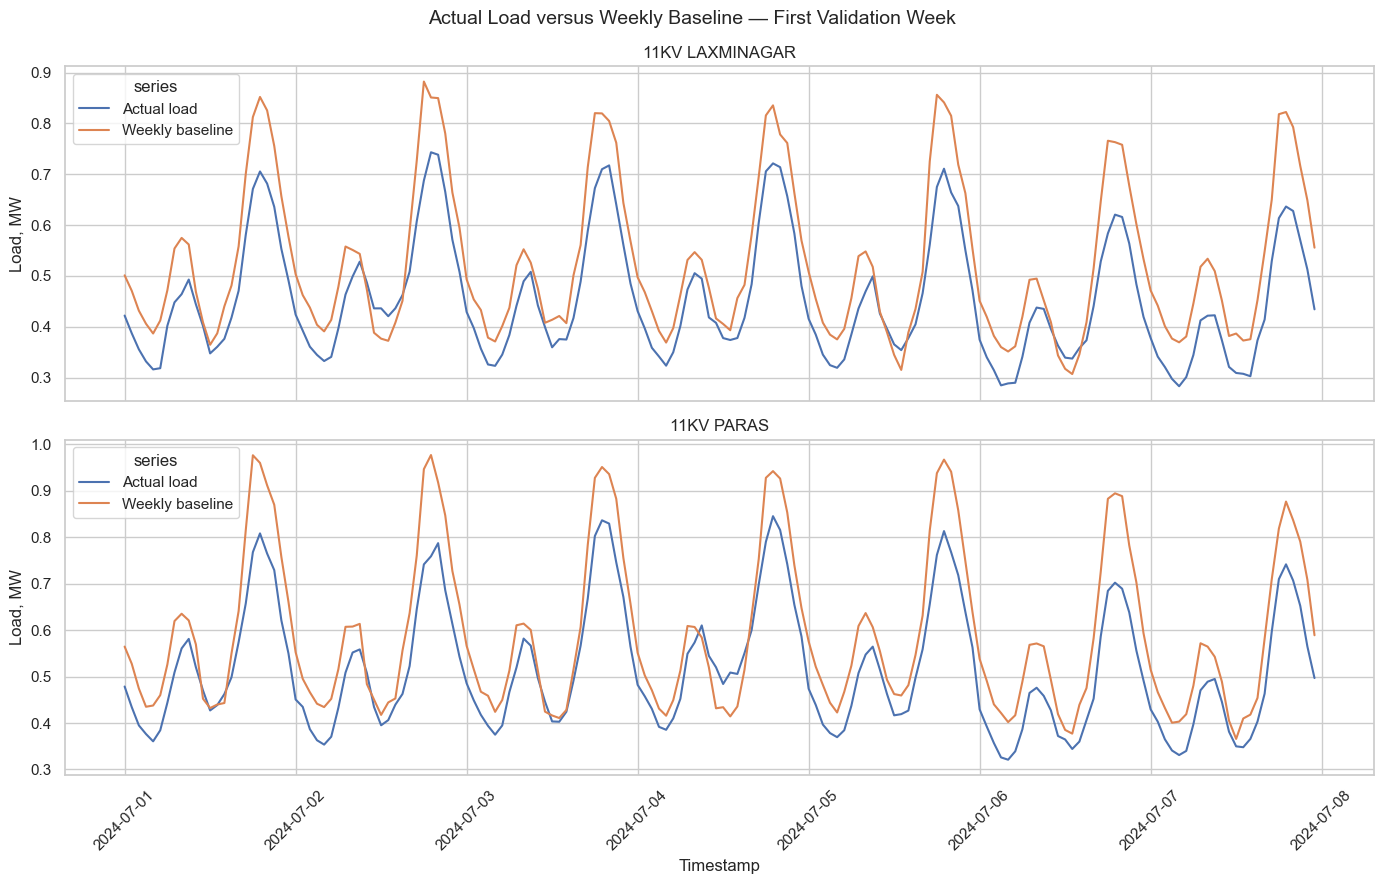

In [68]:
baseline_plot_start = validation_data["timestamp"].min()
baseline_plot_end = baseline_plot_start + pd.Timedelta(days=7)

baseline_plot_data = validation_data[
    (validation_data["timestamp"] >= baseline_plot_start)
    & (validation_data["timestamp"] < baseline_plot_end)
][
    ["timestamp", "Feeder Name", target_column, "load_lag_168"]
].copy()

baseline_plot_data = baseline_plot_data.rename(columns={
    target_column: "Actual load",
    "load_lag_168": "Weekly baseline",
})

baseline_plot_long = baseline_plot_data.melt(
    id_vars=["timestamp", "Feeder Name"],
    value_vars=["Actual load", "Weekly baseline"],
    var_name="series",
    value_name="load_mw",
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for axis, feeder_name in zip(
    axes, sorted(baseline_plot_long["Feeder Name"].unique())
):
    feeder_plot = baseline_plot_long[
        baseline_plot_long["Feeder Name"] == feeder_name
    ]
    sns.lineplot(
        data=feeder_plot,
        x="timestamp",
        y="load_mw",
        hue="series",
        ax=axis,
    )
    axis.set_title(feeder_name)
    axis.set_xlabel("Timestamp")
    axis.set_ylabel("Load, MW")

fig.suptitle("Actual Load versus Weekly Baseline — First Validation Week", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Multiple Linear Regression

Linear Regression provides a simple machine-learning benchmark. Because the input features use different units and ranges, a pipeline standardizes them using statistics learned only from the training period before fitting the regression model.

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

linear_regression_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_regression_model.fit(X_train, y_train)
linear_validation_predictions = linear_regression_model.predict(X_validation)

print("Linear Regression training complete.")

Linear Regression training complete.


## Evaluate Linear Regression on validation data

The validation period was not used to fit the scaler or regression coefficients. It therefore provides an honest comparison with the weekly baseline during model development.

In [70]:
linear_overall_metrics = calculate_regression_metrics(
    y_validation,
    linear_validation_predictions,
)

linear_overall_results = pd.DataFrame([{
    "model": "Multiple Linear Regression",
    "scope": "Overall validation",
    **linear_overall_metrics,
}])

validation_model_comparison = pd.concat(
    [baseline_overall_results, linear_overall_results],
    ignore_index=True,
)

validation_model_comparison.round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,Overall validation,0.025,0.0343,0.9334
1,Multiple Linear Regression,Overall validation,0.019,0.0250,0.9645


## Evaluate Linear Regression separately for each feeder

We attach predictions to the matching validation rows and calculate independent feeder-level metrics.

In [71]:
linear_validation_results_data = validation_data[
    ["timestamp", "Feeder Name", target_column]
].copy()
linear_validation_results_data["prediction"] = linear_validation_predictions

linear_feeder_results = []

for feeder_name, feeder_rows in linear_validation_results_data.groupby("Feeder Name"):
    feeder_metrics = calculate_regression_metrics(
        feeder_rows[target_column],
        feeder_rows["prediction"],
    )
    linear_feeder_results.append({
        "model": "Multiple Linear Regression",
        "scope": feeder_name,
        **feeder_metrics,
    })

linear_feeder_results = pd.DataFrame(linear_feeder_results)

pd.concat(
    [baseline_feeder_results, linear_feeder_results],
    ignore_index=True,
).round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,11KV LAXMINAGAR,0.0234,0.0321,0.9289
1,Same-hour previous week,11KV PARAS,0.0266,0.0364,0.9318
2,Multiple Linear Regression,11KV LAXMINAGAR,0.0180,0.0234,0.9622
3,Multiple Linear Regression,11KV PARAS,0.0201,0.0265,0.9637


## Compare Linear Regression and the weekly baseline visually

We use the same first validation week and display actual load, weekly-baseline predictions, and Linear Regression predictions. This reveals whether the regression model improves the hourly shape and peak estimates.

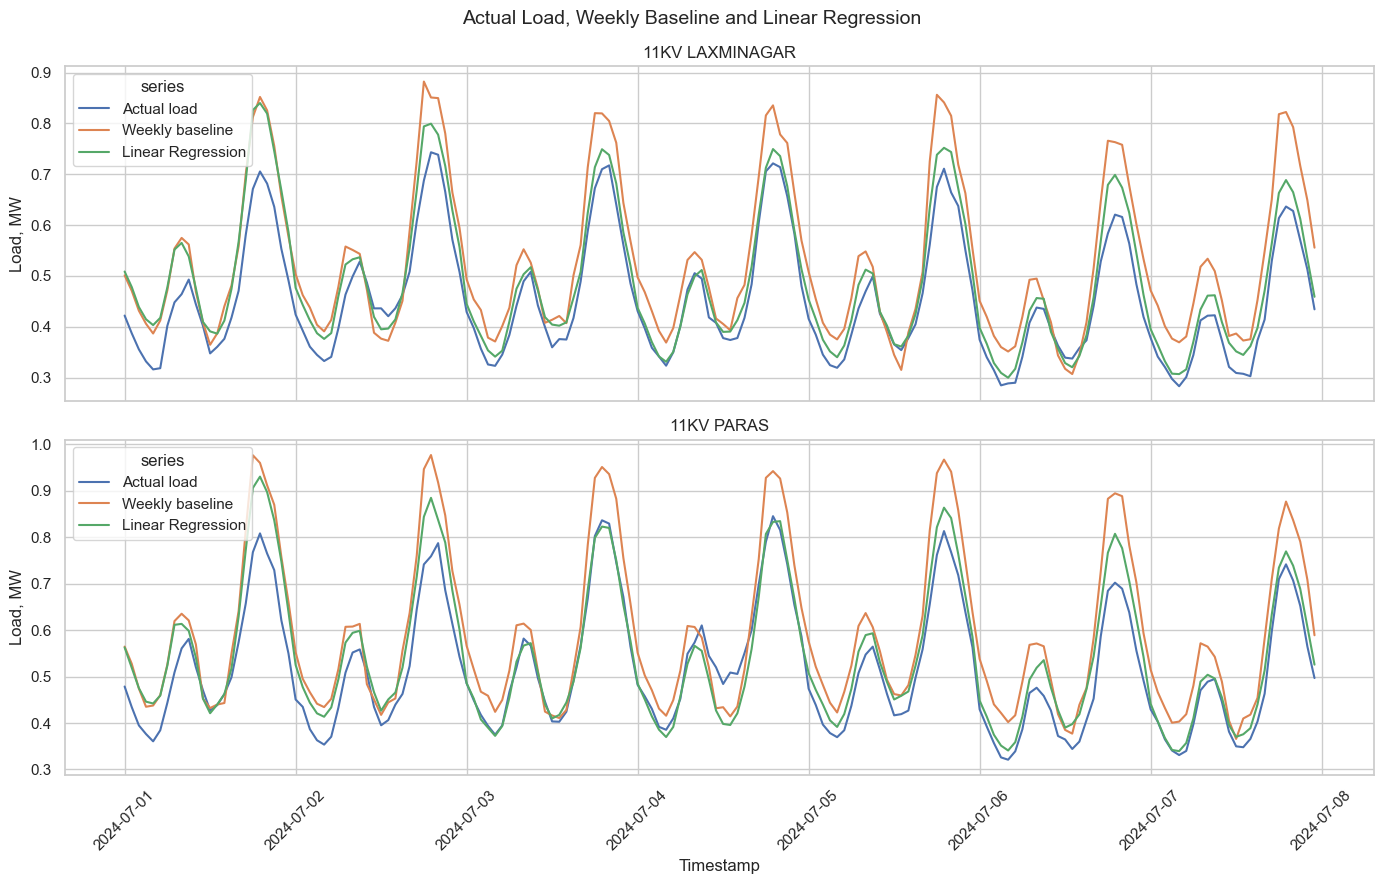

In [72]:
validation_prediction_data = validation_data[
    ["timestamp", "Feeder Name", target_column, "load_lag_168"]
].copy()

validation_prediction_data["Linear Regression"] = (
    linear_validation_predictions
)
validation_prediction_data = validation_prediction_data.rename(columns={
    target_column: "Actual load",
    "load_lag_168": "Weekly baseline",
})

comparison_week = validation_prediction_data[
    (validation_prediction_data["timestamp"] >= baseline_plot_start)
    & (validation_prediction_data["timestamp"] < baseline_plot_end)
]

comparison_week_long = comparison_week.melt(
    id_vars=["timestamp", "Feeder Name"],
    value_vars=["Actual load", "Weekly baseline", "Linear Regression"],
    var_name="series",
    value_name="load_mw",
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for axis, feeder_name in zip(
    axes, sorted(comparison_week_long["Feeder Name"].unique())
):
    feeder_plot = comparison_week_long[
        comparison_week_long["Feeder Name"] == feeder_name
    ]
    sns.lineplot(
        data=feeder_plot,
        x="timestamp",
        y="load_mw",
        hue="series",
        ax=axis,
    )
    axis.set_title(feeder_name)
    axis.set_xlabel("Timestamp")
    axis.set_ylabel("Load, MW")

fig.suptitle("Actual Load, Weekly Baseline and Linear Regression", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Initial Random Forest model

Random Forest trains many decision trees on different samples and averages their predictions. It can capture nonlinear relationships and feature interactions without standardizing the inputs. We first fit an untuned model to establish a reference before hyperparameter search.

In [73]:
from time import perf_counter
from sklearn.ensemble import RandomForestRegressor

random_forest_initial = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

rf_start_time = perf_counter()
random_forest_initial.fit(X_train, y_train)
rf_training_seconds = perf_counter() - rf_start_time

rf_validation_predictions = random_forest_initial.predict(X_validation)

print(f"Random Forest training time: {rf_training_seconds:.2f} seconds")

Random Forest training time: 30.05 seconds


## Evaluate the initial Random Forest

The model is evaluated on exactly the same validation observations as the baseline and Linear Regression, allowing a direct comparison.

In [74]:
rf_overall_metrics = calculate_regression_metrics(
    y_validation,
    rf_validation_predictions,
)

rf_overall_results = pd.DataFrame([{
    "model": "Random Forest (initial)",
    "scope": "Overall validation",
    **rf_overall_metrics,
}])

validation_model_comparison = pd.concat(
    [
        baseline_overall_results,
        linear_overall_results,
        rf_overall_results,
    ],
    ignore_index=True,
)

validation_model_comparison.round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,Overall validation,0.025,0.0343,0.9334
1,Multiple Linear Regression,Overall validation,0.019,0.0250,0.9645
2,Random Forest (initial),Overall validation,0.019,0.0251,0.9645


## Evaluate the initial Random Forest by feeder

Feeder-level metrics check whether the combined model performs consistently across both load series.

In [75]:
rf_validation_results_data = validation_data[
    ["timestamp", "Feeder Name", target_column]
].copy()
rf_validation_results_data["prediction"] = rf_validation_predictions

rf_feeder_results = []

for feeder_name, feeder_rows in rf_validation_results_data.groupby("Feeder Name"):
    feeder_metrics = calculate_regression_metrics(
        feeder_rows[target_column],
        feeder_rows["prediction"],
    )
    rf_feeder_results.append({
        "model": "Random Forest (initial)",
        "scope": feeder_name,
        **feeder_metrics,
    })

rf_feeder_results = pd.DataFrame(rf_feeder_results)

pd.concat(
    [baseline_feeder_results, linear_feeder_results, rf_feeder_results],
    ignore_index=True,
).round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,11KV LAXMINAGAR,0.0234,0.0321,0.9289
1,Same-hour previous week,11KV PARAS,0.0266,0.0364,0.9318
2,Multiple Linear Regression,11KV LAXMINAGAR,0.0180,0.0234,0.9622
3,Multiple Linear Regression,11KV PARAS,0.0201,0.0265,0.9637
4,Random Forest (initial),11KV LAXMINAGAR,0.0180,0.0238,0.9610
5,Random Forest (initial),11KV PARAS,0.0200,0.0262,0.9645


## Compare the initial Random Forest visually

We add the initial Random Forest predictions to the same validation-week comparison. All lines refer to identical timestamps, allowing visual comparison of shape, peaks, and deviations from actual load.

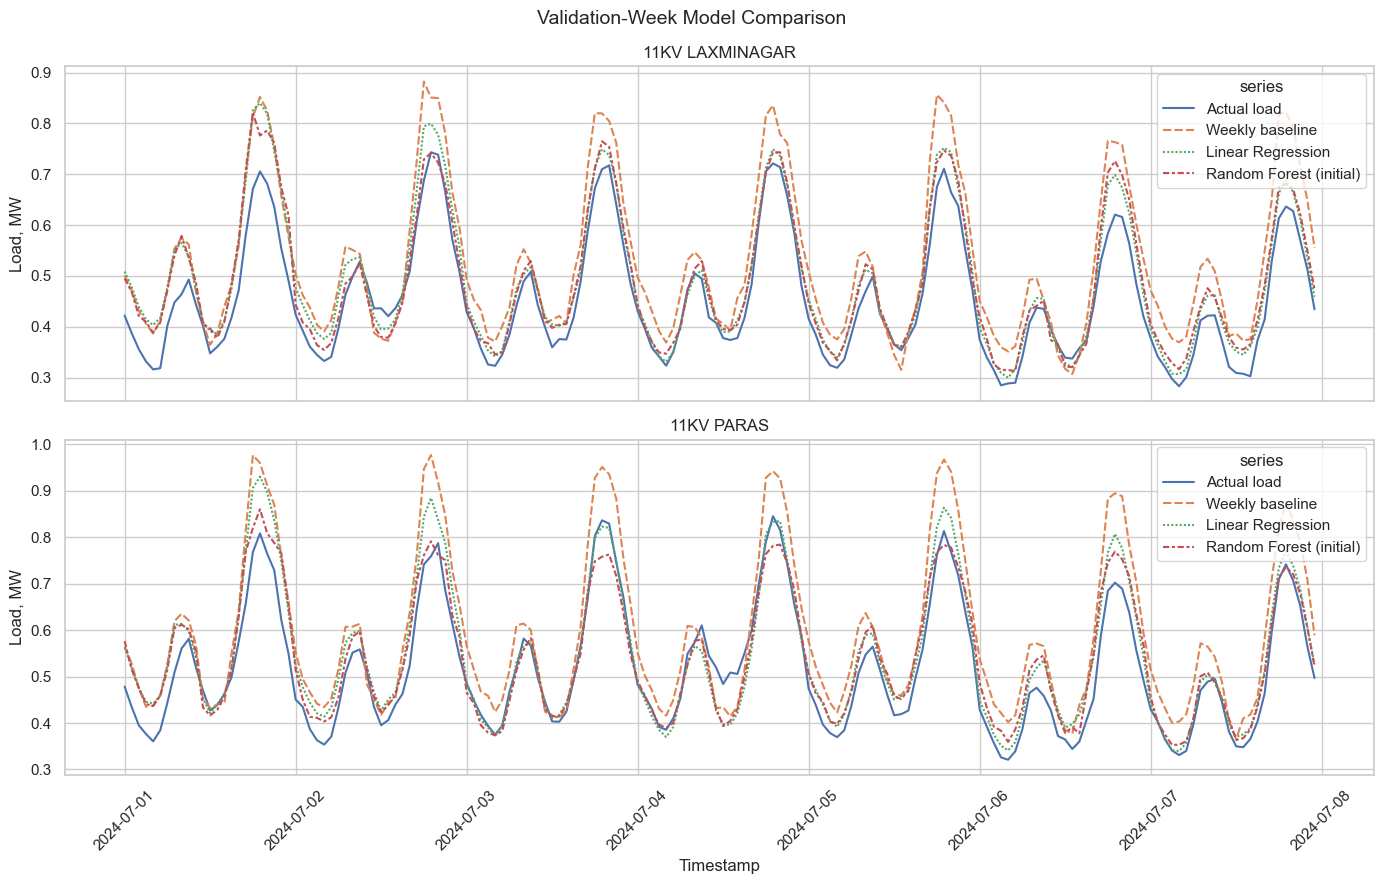

In [76]:
validation_prediction_data["Random Forest (initial)"] = (
    rf_validation_predictions
)

rf_comparison_week = validation_prediction_data[
    (validation_prediction_data["timestamp"] >= baseline_plot_start)
    & (validation_prediction_data["timestamp"] < baseline_plot_end)
]

rf_comparison_week_long = rf_comparison_week.melt(
    id_vars=["timestamp", "Feeder Name"],
    value_vars=[
        "Actual load",
        "Weekly baseline",
        "Linear Regression",
        "Random Forest (initial)",
    ],
    var_name="series",
    value_name="load_mw",
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for axis, feeder_name in zip(
    axes, sorted(rf_comparison_week_long["Feeder Name"].unique())
):
    feeder_plot = rf_comparison_week_long[
        rf_comparison_week_long["Feeder Name"] == feeder_name
    ]
    sns.lineplot(
        data=feeder_plot,
        x="timestamp",
        y="load_mw",
        hue="series",
        style="series",
        ax=axis,
    )
    axis.set_title(feeder_name)
    axis.set_xlabel("Timestamp")
    axis.set_ylabel("Load, MW")

fig.suptitle("Validation-Week Model Comparison", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Random Forest hyperparameter tuning

Hyperparameters control how the forest is constructed. We use a moderate randomized search with expanding chronological folds. Tuning uses only the training period; the fixed July–December 2024 validation period remains outside the search.

## Build timestamp-based cross-validation folds

There are two feeder rows at each timestamp. We split unique timestamps first and then map them back to row positions, ensuring that the same hour never appears in both training and validation portions of a fold.

In [77]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

unique_training_timestamps = np.sort(training_data["timestamp"].unique())
timestamp_splitter = TimeSeriesSplit(n_splits=3)
temporal_cv_splits = []
temporal_fold_summary = []

for fold_number, (train_time_positions, validation_time_positions) in enumerate(
    timestamp_splitter.split(unique_training_timestamps),
    start=1,
):
    fold_train_timestamps = unique_training_timestamps[train_time_positions]
    fold_validation_timestamps = unique_training_timestamps[validation_time_positions]

    fold_train_rows = np.flatnonzero(
        training_data["timestamp"].isin(fold_train_timestamps).to_numpy()
    )
    fold_validation_rows = np.flatnonzero(
        training_data["timestamp"].isin(fold_validation_timestamps).to_numpy()
    )

    temporal_cv_splits.append((fold_train_rows, fold_validation_rows))
    temporal_fold_summary.append({
        "fold": fold_number,
        "training_start": fold_train_timestamps.min(),
        "training_end": fold_train_timestamps.max(),
        "validation_start": fold_validation_timestamps.min(),
        "validation_end": fold_validation_timestamps.max(),
        "training_rows": len(fold_train_rows),
        "validation_rows": len(fold_validation_rows),
    })

temporal_fold_summary = pd.DataFrame(temporal_fold_summary)
temporal_fold_summary

,fold,training_start,training_end,validation_start,validation_end,training_rows,validation_rows
0,1,2023-01-08 23:00:00,2023-05-23 17:00:00,2023-05-23 18:00:00,2023-10-05 11:00:00,6470,6468
1,2,2023-01-08 23:00:00,2023-10-05 11:00:00,2023-10-05 12:00:00,2024-02-17 05:00:00,12938,6468
2,3,2023-01-08 23:00:00,2024-02-17 05:00:00,2024-02-17 06:00:00,2024-06-30 23:00:00,19406,6468


## Search a moderate Random Forest parameter space

The search evaluates 12 randomly selected parameter combinations. Mean Absolute Error is the tuning objective, while RMSE and R-squared will still be reported when evaluating the selected model.

In [78]:
random_forest_parameter_space = {
    "n_estimators": [150, 250, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0],
}

rf_search_estimator = RandomForestRegressor(
    random_state=42,
    n_jobs=1,
)

random_forest_search = RandomizedSearchCV(
    estimator=rf_search_estimator,
    param_distributions=random_forest_parameter_space,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

rf_tuning_start = perf_counter()
random_forest_search.fit(X_train, y_train)
rf_tuning_seconds = perf_counter() - rf_tuning_start

print(f"Tuning time: {rf_tuning_seconds:.2f} seconds")
print(f"Best cross-validated MAE: {-random_forest_search.best_score_:.6f} MW")
print("Best parameters:")
display(random_forest_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tuning time: 332.39 seconds
Best cross-validated MAE: 0.020885 MW
Best parameters:


{'n_estimators': 400,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 30}

## Evaluate the tuned Random Forest on the fixed validation period

The search automatically refits its best parameter combination on all training rows. We now apply that selected estimator to the untouched fixed validation period.

In [79]:
random_forest_tuned = random_forest_search.best_estimator_
rf_tuned_validation_predictions = random_forest_tuned.predict(X_validation)

rf_tuned_overall_metrics = calculate_regression_metrics(
    y_validation,
    rf_tuned_validation_predictions,
)

rf_tuned_overall_results = pd.DataFrame([{
    "model": "Random Forest (tuned)",
    "scope": "Overall validation",
    **rf_tuned_overall_metrics,
}])

pd.concat(
    [
        baseline_overall_results,
        linear_overall_results,
        rf_overall_results,
        rf_tuned_overall_results,
    ],
    ignore_index=True,
).round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,Overall validation,0.0250,0.0343,0.9334
1,Multiple Linear Regression,Overall validation,0.0190,0.0250,0.9645
2,Random Forest (initial),Overall validation,0.0190,0.0251,0.9645
3,Random Forest (tuned),Overall validation,0.0179,0.0234,0.9691


## Evaluate the tuned Random Forest by feeder

The hyperparameter search optimized overall training-fold MAE. We therefore inspect fixed-validation performance for each feeder and compare the tuned forest with the initial forest.

In [80]:
rf_tuned_validation_results_data = validation_data[
    ["timestamp", "Feeder Name", target_column]
].copy()
rf_tuned_validation_results_data["prediction"] = (
    rf_tuned_validation_predictions
)

rf_tuned_feeder_results = []

for feeder_name, feeder_rows in rf_tuned_validation_results_data.groupby(
    "Feeder Name"
):
    feeder_metrics = calculate_regression_metrics(
        feeder_rows[target_column],
        feeder_rows["prediction"],
    )
    rf_tuned_feeder_results.append({
        "model": "Random Forest (tuned)",
        "scope": feeder_name,
        **feeder_metrics,
    })

rf_tuned_feeder_results = pd.DataFrame(rf_tuned_feeder_results)

random_forest_feeder_comparison = pd.concat(
    [rf_feeder_results, rf_tuned_feeder_results],
    ignore_index=True,
)

random_forest_feeder_comparison.round(4)

,model,scope,MAE,RMSE,R2
0,Random Forest (initial),11KV LAXMINAGAR,0.0180,0.0238,0.9610
1,Random Forest (initial),11KV PARAS,0.0200,0.0262,0.9645
2,Random Forest (tuned),11KV LAXMINAGAR,0.0169,0.0219,0.9669
3,Random Forest (tuned),11KV PARAS,0.0188,0.0247,0.9685


## Measure the effect of Random Forest tuning

A positive MAE improvement percentage means tuning reduced validation error. A negative percentage means the tuned configuration performed worse than the initial model on the fixed validation period.

In [81]:
rf_tuning_effect = random_forest_feeder_comparison.pivot(
    index="scope",
    columns="model",
    values="MAE",
)

rf_tuning_effect["MAE improvement percent"] = (
    (rf_tuning_effect["Random Forest (initial)"]
     - rf_tuning_effect["Random Forest (tuned)"])
    / rf_tuning_effect["Random Forest (initial)"]
    * 100
)

rf_tuning_effect.round(4)

model,Random Forest (initial),Random Forest (tuned),MAE improvement percent
scope,,,
11KV LAXMINAGAR,0.018,0.0169,5.7051
11KV PARAS,0.020,0.0188,6.1627


# Initial XGBoost model

XGBoost builds trees sequentially. Each new tree focuses on reducing errors left by the earlier trees. We first use reasonable starting settings to establish validation performance before hyperparameter tuning. Feature scaling is not required for this tree-based model.

In [82]:
from xgboost import XGBRegressor

xgboost_initial = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="mae",
)

xgb_start_time = perf_counter()
xgboost_initial.fit(X_train, y_train)
xgb_training_seconds = perf_counter() - xgb_start_time

xgb_validation_predictions = xgboost_initial.predict(X_validation)

print(f"XGBoost training time: {xgb_training_seconds:.2f} seconds")

XGBoost training time: 3.12 seconds


## Evaluate the initial XGBoost model

We evaluate XGBoost on the same fixed validation observations used for the baseline, Linear Regression, and Random Forest.

In [83]:
xgb_overall_metrics = calculate_regression_metrics(
    y_validation,
    xgb_validation_predictions,
)

xgb_overall_results = pd.DataFrame([{
    "model": "XGBoost (initial)",
    "scope": "Overall validation",
    **xgb_overall_metrics,
}])

pd.concat(
    [
        baseline_overall_results,
        linear_overall_results,
        rf_overall_results,
        rf_tuned_overall_results,
        xgb_overall_results,
    ],
    ignore_index=True,
).round(4)

,model,scope,MAE,RMSE,R2
0,Same-hour previous week,Overall validation,0.0250,0.0343,0.9334
1,Multiple Linear Regression,Overall validation,0.0190,0.0250,0.9645
2,Random Forest (initial),Overall validation,0.0190,0.0251,0.9645
3,Random Forest (tuned),Overall validation,0.0179,0.0234,0.9691
4,XGBoost (initial),Overall validation,0.0191,0.0250,0.9647


## Evaluate the initial XGBoost model by feeder

Feeder-level metrics show whether the combined XGBoost model performs consistently for both series.

In [84]:
xgb_validation_results_data = validation_data[
    ["timestamp", "Feeder Name", target_column]
].copy()
xgb_validation_results_data["prediction"] = xgb_validation_predictions

xgb_feeder_results = []

for feeder_name, feeder_rows in xgb_validation_results_data.groupby("Feeder Name"):
    feeder_metrics = calculate_regression_metrics(
        feeder_rows[target_column],
        feeder_rows["prediction"],
    )
    xgb_feeder_results.append({
        "model": "XGBoost (initial)",
        "scope": feeder_name,
        **feeder_metrics,
    })

xgb_feeder_results = pd.DataFrame(xgb_feeder_results)

xgb_feeder_results.round(4)

,model,scope,MAE,RMSE,R2
0,XGBoost (initial),11KV LAXMINAGAR,0.0171,0.0222,0.9662
1,XGBoost (initial),11KV PARAS,0.0211,0.0275,0.9610


## Compare the initial XGBoost model visually

We add initial XGBoost predictions to the first validation week and compare them with actual load, Linear Regression, and the tuned Random Forest. The earlier chart already provides the weekly-baseline comparison.

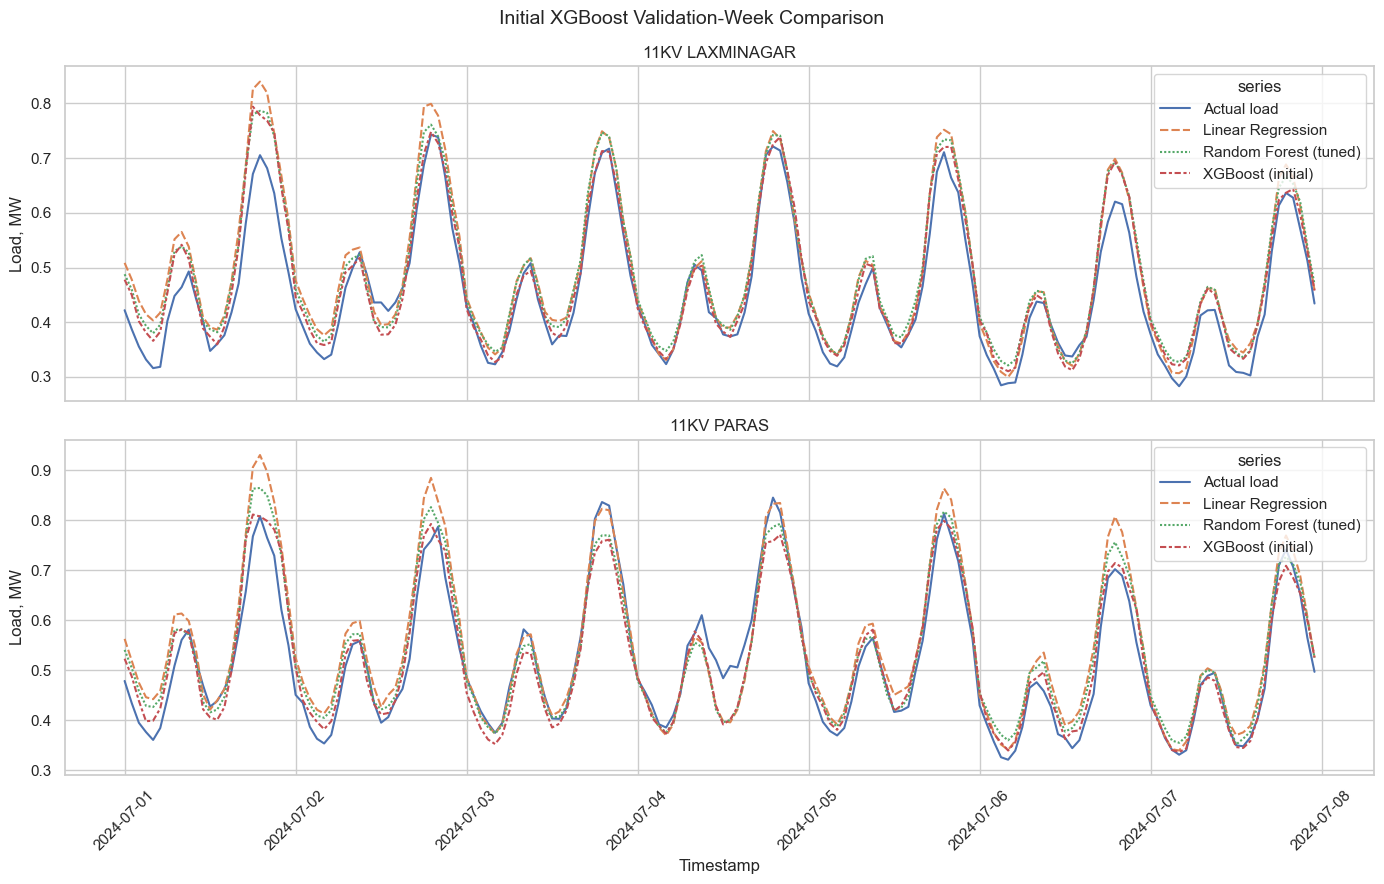

In [85]:
validation_prediction_data["Random Forest (tuned)"] = (
    rf_tuned_validation_predictions
)
validation_prediction_data["XGBoost (initial)"] = (
    xgb_validation_predictions
)

xgb_comparison_week = validation_prediction_data[
    (validation_prediction_data["timestamp"] >= baseline_plot_start)
    & (validation_prediction_data["timestamp"] < baseline_plot_end)
]

xgb_comparison_week_long = xgb_comparison_week.melt(
    id_vars=["timestamp", "Feeder Name"],
    value_vars=[
        "Actual load",
        "Linear Regression",
        "Random Forest (tuned)",
        "XGBoost (initial)",
    ],
    var_name="series",
    value_name="load_mw",
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for axis, feeder_name in zip(
    axes, sorted(xgb_comparison_week_long["Feeder Name"].unique())
):
    feeder_plot = xgb_comparison_week_long[
        xgb_comparison_week_long["Feeder Name"] == feeder_name
    ]
    sns.lineplot(
        data=feeder_plot,
        x="timestamp",
        y="load_mw",
        hue="series",
        style="series",
        ax=axis,
    )
    axis.set_title(feeder_name)
    axis.set_xlabel("Timestamp")
    axis.set_ylabel("Load, MW")

fig.suptitle("Initial XGBoost Validation-Week Comparison", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# XGBoost hyperparameter tuning

We use a moderate randomized search with the previously constructed chronological folds. The search optimizes cross-validated MAE using only the training period.

## Define the XGBoost parameter space

The search considers tree quantity, learning rate, tree complexity, row and feature sampling, and regularization. Twelve parameter combinations keep the experiment appropriate for the project scope.

In [86]:
xgboost_parameter_space = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0.0, 0.01, 0.10],
    "reg_lambda": [1.0, 2.0, 5.0],
}

xgboost_search_estimator = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
    tree_method="hist",
    eval_metric="mae",
    verbosity=0,
)

xgboost_search = RandomizedSearchCV(
    estimator=xgboost_search_estimator,
    param_distributions=xgboost_parameter_space,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=temporal_cv_splits,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

xgb_tuning_start = perf_counter()
xgboost_search.fit(X_train, y_train)
xgb_tuning_seconds = perf_counter() - xgb_tuning_start

print(f"Tuning time: {xgb_tuning_seconds:.2f} seconds")
print(f"Best cross-validated MAE: {-xgboost_search.best_score_:.6f} MW")
print("Best parameters:")
display(xgboost_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tuning time: 40.76 seconds
Best cross-validated MAE: 0.023336 MW
Best parameters:


{'subsample': 0.85,
 'reg_lambda': 5.0,
 'reg_alpha': 0.0,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

## Evaluate the tuned XGBoost model on fixed validation data

The best parameter combination is automatically refitted on all training rows. We then evaluate it on the fixed validation period that was excluded from the search.

In [87]:
xgboost_tuned = xgboost_search.best_estimator_
xgb_tuned_validation_predictions = xgboost_tuned.predict(X_validation)

xgb_tuned_overall_metrics = calculate_regression_metrics(
    y_validation,
    xgb_tuned_validation_predictions,
)

xgb_tuned_overall_results = pd.DataFrame([{
    "model": "XGBoost (tuned)",
    "scope": "Overall validation",
    **xgb_tuned_overall_metrics,
}])

complete_validation_comparison = pd.concat(
    [
        baseline_overall_results,
        linear_overall_results,
        rf_overall_results,
        rf_tuned_overall_results,
        xgb_overall_results,
        xgb_tuned_overall_results,
    ],
    ignore_index=True,
)

complete_validation_comparison.sort_values("MAE").round(4)

,model,scope,MAE,RMSE,R2
3,Random Forest (tuned),Overall validation,0.0179,0.0234,0.9691
2,Random Forest (initial),Overall validation,0.0190,0.0251,0.9645
1,Multiple Linear Regression,Overall validation,0.0190,0.0250,0.9645
4,XGBoost (initial),Overall validation,0.0191,0.0250,0.9647
5,XGBoost (tuned),Overall validation,0.0197,0.0258,0.9623
0,Same-hour previous week,Overall validation,0.0250,0.0343,0.9334


## Evaluate the tuned XGBoost model by feeder

The tuning search optimized combined cross-validation MAE. We now verify fixed-validation performance separately for both feeder series.

In [88]:
xgb_tuned_validation_results_data = validation_data[
    ["timestamp", "Feeder Name", target_column]
].copy()
xgb_tuned_validation_results_data["prediction"] = (
    xgb_tuned_validation_predictions
)

xgb_tuned_feeder_results = []

for feeder_name, feeder_rows in xgb_tuned_validation_results_data.groupby(
    "Feeder Name"
):
    feeder_metrics = calculate_regression_metrics(
        feeder_rows[target_column],
        feeder_rows["prediction"],
    )
    xgb_tuned_feeder_results.append({
        "model": "XGBoost (tuned)",
        "scope": feeder_name,
        **feeder_metrics,
    })

xgb_tuned_feeder_results = pd.DataFrame(xgb_tuned_feeder_results)

xgboost_feeder_comparison = pd.concat(
    [xgb_feeder_results, xgb_tuned_feeder_results],
    ignore_index=True,
)

xgboost_feeder_comparison.round(4)

,model,scope,MAE,RMSE,R2
0,XGBoost (initial),11KV LAXMINAGAR,0.0171,0.0222,0.9662
1,XGBoost (initial),11KV PARAS,0.0211,0.0275,0.9610
2,XGBoost (tuned),11KV LAXMINAGAR,0.0179,0.0234,0.9622
3,XGBoost (tuned),11KV PARAS,0.0215,0.0280,0.9595


## Measure the effect of XGBoost tuning

A positive improvement percentage means tuning reduced fixed-validation MAE for that feeder. A negative value means the initial settings generalized better to the fixed validation period.

In [89]:
xgb_tuning_effect = xgboost_feeder_comparison.pivot(
    index="scope",
    columns="model",
    values="MAE",
)

xgb_tuning_effect["MAE improvement percent"] = (
    (xgb_tuning_effect["XGBoost (initial)"]
     - xgb_tuning_effect["XGBoost (tuned)"])
    / xgb_tuning_effect["XGBoost (initial)"]
    * 100
)

xgb_tuning_effect.round(4)

model,XGBoost (initial),XGBoost (tuned),MAE improvement percent
scope,,,
11KV LAXMINAGAR,0.0171,0.0179,-5.0674
11KV PARAS,0.0211,0.0215,-1.5597


## Compare selected validation models by feeder

This table combines the baseline, Linear Regression, tuned Random Forest, and tuned XGBoost results for each feeder. Untuned tree models are omitted here because their role was to measure the effect of tuning.

In [90]:
selected_feeder_validation_comparison = pd.concat(
    [
        baseline_feeder_results,
        linear_feeder_results,
        rf_tuned_feeder_results,
        xgb_tuned_feeder_results,
    ],
    ignore_index=True,
)

selected_feeder_validation_comparison.sort_values(
    ["scope", "MAE"]
).round(4)

,model,scope,MAE,RMSE,R2
4,Random Forest (tuned),11KV LAXMINAGAR,0.0169,0.0219,0.9669
6,XGBoost (tuned),11KV LAXMINAGAR,0.0179,0.0234,0.9622
2,Multiple Linear Regression,11KV LAXMINAGAR,0.0180,0.0234,0.9622
0,Same-hour previous week,11KV LAXMINAGAR,0.0234,0.0321,0.9289
5,Random Forest (tuned),11KV PARAS,0.0188,0.0247,0.9685
3,Multiple Linear Regression,11KV PARAS,0.0201,0.0265,0.9637
7,XGBoost (tuned),11KV PARAS,0.0215,0.0280,0.9595
1,Same-hour previous week,11KV PARAS,0.0266,0.0364,0.9318


# Final validation comparison

We now compare the weekly baseline, Multiple Linear Regression, tuned Random Forest, and tuned XGBoost on the same fixed validation period. The untuned tree models remain documented as intermediate experiments but are excluded from the selected-model summary.

In [91]:
selected_overall_validation_comparison = pd.concat(
    [
        baseline_overall_results,
        linear_overall_results,
        rf_tuned_overall_results,
        xgb_tuned_overall_results,
    ],
    ignore_index=True,
)

baseline_validation_mae = baseline_overall_results.loc[0, "MAE"]
baseline_validation_rmse = baseline_overall_results.loc[0, "RMSE"]

selected_overall_validation_comparison["MAE improvement over baseline (%)"] = (
    (baseline_validation_mae
     - selected_overall_validation_comparison["MAE"])
    / baseline_validation_mae
    * 100
)

selected_overall_validation_comparison["RMSE improvement over baseline (%)"] = (
    (baseline_validation_rmse
     - selected_overall_validation_comparison["RMSE"])
    / baseline_validation_rmse
    * 100
)

selected_overall_validation_comparison = (
    selected_overall_validation_comparison
      .sort_values("MAE")
      .reset_index(drop=True)
)

selected_overall_validation_comparison.round(4)

,model,scope,MAE,RMSE,R2,MAE improvement over baseline (%),RMSE improvement over baseline (%)
0,Random Forest (tuned),Overall validation,0.0179,0.0234,0.9691,28.5387,31.8827
1,Multiple Linear Regression,Overall validation,0.0190,0.0250,0.9645,23.8499,27.0304
2,XGBoost (tuned),Overall validation,0.0197,0.0258,0.9623,21.2239,24.7130
3,Same-hour previous week,Overall validation,0.0250,0.0343,0.9334,0.0000,0.0000


## Plot validation MAE and RMSE

Lower bars indicate better validation performance. MAE represents typical absolute error, while RMSE gives greater weight to larger forecasting errors.

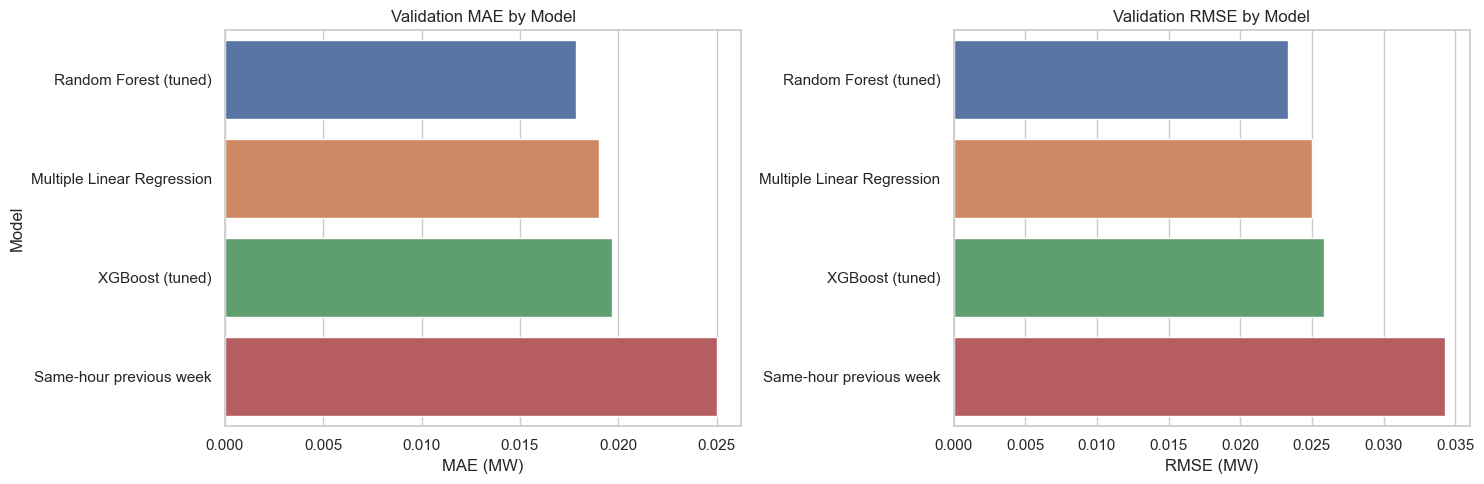

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=selected_overall_validation_comparison,
    x="MAE",
    y="model",
    hue="model",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Validation MAE by Model")
axes[0].set_xlabel("MAE (MW)")
axes[0].set_ylabel("Model")

sns.barplot(
    data=selected_overall_validation_comparison,
    x="RMSE",
    y="model",
    hue="model",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Validation RMSE by Model")
axes[1].set_xlabel("RMSE (MW)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Final model refitting and 2025 test evaluation

All modelling decisions are now treated as fixed. We refit the selected models using the complete 2023–2024 development period and evaluate them once on the untouched 2025 test period. Test results will not be used for further hyperparameter tuning.

## Refit selected models on all development data

Cloning creates fresh model objects with the selected configurations. Random Forest and XGBoost are allowed to use all CPU cores during this final fit.

In [93]:
from sklearn.base import clone

linear_regression_final = clone(linear_regression_model)
random_forest_final = clone(random_forest_tuned).set_params(n_jobs=-1)
xgboost_final = clone(xgboost_tuned).set_params(n_jobs=-1)

final_training_times = {}

start_time = perf_counter()
linear_regression_final.fit(X_development, y_development)
final_training_times["Multiple Linear Regression"] = perf_counter() - start_time

start_time = perf_counter()
random_forest_final.fit(X_development, y_development)
final_training_times["Random Forest (tuned)"] = perf_counter() - start_time

start_time = perf_counter()
xgboost_final.fit(X_development, y_development)
final_training_times["XGBoost (tuned)"] = perf_counter() - start_time

pd.Series(final_training_times, name="training_seconds").to_frame().round(2)

,training_seconds
Multiple Linear Regression,0.17
Random Forest (tuned),15.45
XGBoost (tuned),2.16


## Generate 2025 test predictions

The weekly baseline uses the same-hour load from one week earlier. The three fitted models predict from the fixed 20-feature test matrix.

In [94]:
test_prediction_data = test_data[
    ["timestamp", "Feeder Name", target_column, "load_lag_168"]
].copy()

test_prediction_data = test_prediction_data.rename(columns={
    target_column: "Actual load",
    "load_lag_168": "Weekly baseline",
})

test_prediction_data["Multiple Linear Regression"] = (
    linear_regression_final.predict(X_test)
)
test_prediction_data["Random Forest (tuned)"] = (
    random_forest_final.predict(X_test)
)
test_prediction_data["XGBoost (tuned)"] = (
    xgboost_final.predict(X_test)
)

test_prediction_data.head()

,timestamp,Feeder Name,Actual load,Weekly baseline,Multiple Linear Regression,Random Forest (tuned),XGBoost (tuned)
0,2025-01-01 00:00:00,11KV LAXMINAGAR,0.379723,0.375139,0.378439,0.382215,0.380256
1,2025-01-01 00:00:00,11KV PARAS,0.450945,0.420063,0.412096,0.416655,0.417369
2,2025-01-01 01:00:00,11KV LAXMINAGAR,0.360691,0.340535,0.348383,0.348759,0.347760
3,2025-01-01 01:00:00,11KV PARAS,0.402833,0.392046,0.379653,0.382521,0.384144
4,2025-01-01 02:00:00,11KV LAXMINAGAR,0.326121,0.314481,0.317335,0.320701,0.319008


## Calculate final overall test metrics

Every model is evaluated against the same 2025 actual-load values. The final table is sorted by MAE, with lower MAE and RMSE and higher R-squared indicating better performance.

In [95]:
final_model_names = [
    "Weekly baseline",
    "Multiple Linear Regression",
    "Random Forest (tuned)",
    "XGBoost (tuned)",
]

final_test_results = []

for model_name in final_model_names:
    model_metrics = calculate_regression_metrics(
        test_prediction_data["Actual load"],
        test_prediction_data[model_name],
    )
    final_test_results.append({
        "model": model_name,
        **model_metrics,
    })

final_test_results = pd.DataFrame(final_test_results)

test_baseline_mae = final_test_results.loc[
    final_test_results["model"] == "Weekly baseline", "MAE"
].iloc[0]
test_baseline_rmse = final_test_results.loc[
    final_test_results["model"] == "Weekly baseline", "RMSE"
].iloc[0]

final_test_results["MAE improvement over baseline (%)"] = (
    (test_baseline_mae - final_test_results["MAE"])
    / test_baseline_mae
    * 100
)
final_test_results["RMSE improvement over baseline (%)"] = (
    (test_baseline_rmse - final_test_results["RMSE"])
    / test_baseline_rmse
    * 100
)

final_test_results = (
    final_test_results.sort_values("MAE")
      .reset_index(drop=True)
)

final_test_results.round(4)

,model,MAE,RMSE,R2,MAE improvement over baseline (%),RMSE improvement over baseline (%)
0,Random Forest (tuned),0.0193,0.0257,0.9727,27.6775,28.6115
1,Multiple Linear Regression,0.0203,0.0267,0.9706,23.7754,25.9347
2,XGBoost (tuned),0.0207,0.0273,0.9691,22.3569,24.0631
3,Weekly baseline,0.0266,0.0360,0.9463,0.0000,0.0000


**Final-test rule:** The 2025 results are used for final reporting, not for another round of feature selection or hyperparameter tuning.

# Visualize and interpret final test performance

These plots use the predictions already produced for 2025. They do not retrain or tune any model. Lower MAE and RMSE values are better.

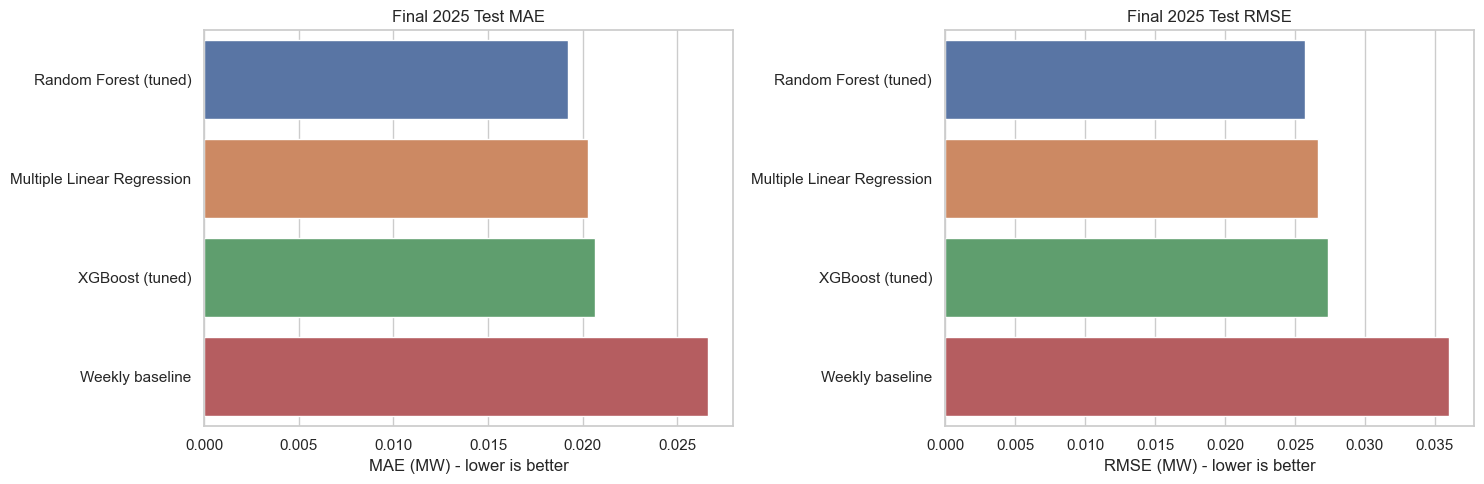

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=final_test_results, x="MAE", y="model",
    hue="model", legend=False, ax=axes[0]
)
axes[0].set_title("Final 2025 Test MAE")
axes[0].set_xlabel("MAE (MW) - lower is better")
axes[0].set_ylabel("")

sns.barplot(
    data=final_test_results, x="RMSE", y="model",
    hue="model", legend=False, ax=axes[1]
)
axes[1].set_title("Final 2025 Test RMSE")
axes[1].set_xlabel("RMSE (MW) - lower is better")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Check final performance separately for each feeder

An overall average can hide poor performance on one feeder. Therefore, the same metrics are calculated independently for both feeders.

In [ ]:
feeder_test_results = []

for feeder_name, feeder_rows in test_prediction_data.groupby("Feeder Name"):
    for model_name in final_model_names:
        feeder_metrics = calculate_regression_metrics(
            feeder_rows["Actual load"],
            feeder_rows[model_name],
        )
        feeder_test_results.append({
            "Feeder Name": feeder_name,
            "model": model_name,
            **feeder_metrics,
        })

feeder_test_results = pd.DataFrame(feeder_test_results)
feeder_test_results.round(4)

## View actual and predicted load for one test week

This line chart checks whether the models follow the hourly peaks and low-load periods. One week is shown to keep the chart readable.

In [ ]:
test_week_start = test_prediction_data["timestamp"].min()
test_week_end = test_week_start + pd.Timedelta(days=7)
test_week = test_prediction_data[
    test_prediction_data["timestamp"].between(
        test_week_start, test_week_end, inclusive="left"
    )
].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for axis, (feeder_name, feeder_rows) in zip(
    axes, test_week.groupby("Feeder Name")
):
    axis.plot(feeder_rows["timestamp"], feeder_rows["Actual load"],
              label="Actual load", color="black", linewidth=2.2)
    for model_name in final_model_names:
        axis.plot(feeder_rows["timestamp"], feeder_rows[model_name],
                  label=model_name, alpha=0.8)
    axis.set_title(f"{feeder_name}: first week of 2025")
    axis.set_ylabel("Load (MW)")
    axis.legend(ncol=3)
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

# Rank and save all forecasting models

The trained models are ranked using the fixed 2024 validation MAE. The 2025 test results remain final reporting evidence and are not used for ranking. Rank 1 becomes the recommended dashboard default, while the instructor can still choose any trained model or the weekly baseline.

In [102]:
deployable_model_names = [
    "Multiple Linear Regression",
    "Random Forest (tuned)",
    "XGBoost (tuned)",
]

deployable_validation_results = (
    selected_overall_validation_comparison[
        selected_overall_validation_comparison["model"].isin(deployable_model_names)
    ]
    .sort_values("MAE")
    .reset_index(drop=True)
)

deployable_validation_results.insert(
    0, "performance_rank", range(1, len(deployable_validation_results) + 1)
)
deployable_validation_results["dashboard_label"] = (
    "Rank "
    + deployable_validation_results["performance_rank"].astype(str)
    + " - "
    + deployable_validation_results["model"]
)

recommended_model_name = deployable_validation_results.loc[0, "model"]
print(f"Recommended model: {recommended_model_name}")
display(deployable_validation_results.round(4))

Recommended model: Random Forest (tuned)


,performance_rank,model,scope,MAE,RMSE,R2,MAE improvement over baseline (%),RMSE improvement over baseline (%),dashboard_label
0,1,Random Forest (tuned),Overall validation,0.0179,0.0234,0.9691,28.5387,31.8827,Rank 1 - Random Forest (tuned)
1,2,Multiple Linear Regression,Overall validation,0.0190,0.0250,0.9645,23.8499,27.0304,Rank 2 - Multiple Linear Regression
2,3,XGBoost (tuned),Overall validation,0.0197,0.0258,0.9623,21.2239,24.7130,Rank 3 - XGBoost (tuned)


## Save all fitted models and supporting information

The saved bundle contains all three models already refitted on usable 2023-2024 data, their validation-based ranking, the exact feature order, feeder mapping, target name and evaluation summaries. The weekly baseline needs no fitted object because the dashboard calculates it directly from the previous week's load.

In [103]:
from pathlib import Path
import joblib

final_fitted_models = {
    "Multiple Linear Regression": linear_regression_final,
    "Random Forest (tuned)": random_forest_final,
    "XGBoost (tuned)": xgboost_final,
}
model_bundle = {
    "models": final_fitted_models,
    "recommended_model_name": recommended_model_name,
    "model_ranking": deployable_validation_results.to_dict(orient="records"),
    "dashboard_model_options": ["Same-hour previous week"]
        + deployable_validation_results["dashboard_label"].tolist(),
    "feature_columns": candidate_feature_columns,
    "feeder_mapping": feeder_mapping,
    "target_column": target_column,
    "ranking_method": "Ascending MAE on fixed 2024 validation period",
    "validation_results": selected_overall_validation_comparison.to_dict(orient="records"),
    "test_results": final_test_results.to_dict(orient="records"),
}

models_directory = Path("models")
models_directory.mkdir(exist_ok=True)
model_file_path = models_directory / "final_load_forecasting_bundle.joblib"
joblib.dump(model_bundle, model_file_path)

print(f"Saved model bundle to: {model_file_path.resolve()}")
print(f"Saved trained models: {list(final_fitted_models)}")
print("Dashboard also includes: Same-hour previous week baseline")
print(f"Recommended default: {recommended_model_name}")
print(f"Number of input features: {len(candidate_feature_columns)}")

Saved model bundle to: E:\MLDAProject\models\final_load_forecasting_bundle.joblib
Saved trained models: ['Multiple Linear Regression', 'Random Forest (tuned)', 'XGBoost (tuned)']
Dashboard also includes: Same-hour previous week baseline
Recommended default: Random Forest (tuned)
Number of input features: 20


After running the saving cell, `models/final_load_forecasting_bundle.joblib` can be loaded by the dashboard without retraining the notebook. The dashboard will show the baseline plus Rank 1, Rank 2 and Rank 3 model choices. Do not edit this binary file manually.

# Prepare 2026 external inputs for the forecast demonstration

The dashboard will use synthetic hourly temperature and humidity for Rajkot and Gujarat public-holiday information for 2026. At this stage we only load, validate and merge these external inputs; load-lag values will be prepared separately.

In [105]:
weather_2026 = pd.read_csv(
    "external_data/rajkot_synthetic_weather_2026.csv",
    parse_dates=["timestamp"],
)
holidays_2026 = pd.read_csv(
    "external_data/gujarat_public_holidays_2026.csv",
    parse_dates=["date"],
)

print("Weather shape:", weather_2026.shape)
print("Holiday shape:", holidays_2026.shape)
display(weather_2026.head())
display(holidays_2026.head())

Weather shape: (8760, 3)
Holiday shape: (26, 2)


,timestamp,temperature_c,humidity_percent
0,2026-01-01 00:00:00,17.3,62
1,2026-01-01 01:00:00,16.3,64
2,2026-01-01 02:00:00,16.0,68
3,2026-01-01 03:00:00,15.8,68
4,2026-01-01 04:00:00,14.7,72


,date,holiday_name
0,2026-01-14,Uttarayan
1,2026-01-26,Republic Day
2,2026-03-04,Holi
3,2026-03-19,Cheti Chand
4,2026-03-21,Eid al-Fitr


## Validate the 2026 files

A complete non-leap year must contain 8,760 hourly timestamps. We also check missing values, duplicate timestamps, chronological order and one-hour continuity before using the files.

In [106]:
expected_2026_timestamps = pd.date_range(
    start="2026-01-01 00:00:00",
    end="2026-12-31 23:00:00",
    freq="h",
)

weather_2026 = weather_2026.sort_values("timestamp").reset_index(drop=True)
missing_2026_timestamps = expected_2026_timestamps.difference(
    weather_2026["timestamp"]
)
unexpected_2026_timestamps = pd.DatetimeIndex(
    weather_2026["timestamp"]
).difference(expected_2026_timestamps)

weather_validation_2026 = pd.Series({
    "row_count": len(weather_2026),
    "expected_row_count": len(expected_2026_timestamps),
    "missing_values": int(weather_2026.isna().sum().sum()),
    "duplicate_timestamps": int(weather_2026["timestamp"].duplicated().sum()),
    "missing_timestamps": len(missing_2026_timestamps),
    "unexpected_timestamps": len(unexpected_2026_timestamps),
    "first_timestamp": weather_2026["timestamp"].min(),
    "last_timestamp": weather_2026["timestamp"].max(),
})

holiday_validation_2026 = pd.Series({
    "row_count": len(holidays_2026),
    "missing_values": int(holidays_2026.isna().sum().sum()),
    "duplicate_dates": int(holidays_2026["date"].duplicated().sum()),
})

print("2026 weather validation:")
display(weather_validation_2026.to_frame("value"))
print("2026 holiday validation:")
display(holiday_validation_2026.to_frame("value"))

2026 weather validation:


,value
row_count,8760
expected_row_count,8760
missing_values,0
duplicate_timestamps,0
missing_timestamps,0
unexpected_timestamps,0
first_timestamp,2026-01-01 00:00:00
last_timestamp,2026-12-31 23:00:00


2026 holiday validation:


,value
row_count,26
missing_values,0
duplicate_dates,0


## Merge weather and the holiday flag

Each hourly weather row is matched to its calendar date. Ordinary dates receive `is_holiday = 0`; listed Gujarat public holidays receive `is_holiday = 1`.

In [107]:
future_external_data_2026 = weather_2026.copy()
future_external_data_2026["date"] = (
    future_external_data_2026["timestamp"].dt.normalize()
)

future_external_data_2026 = future_external_data_2026.merge(
    holidays_2026,
    on="date",
    how="left",
    validate="many_to_one",
)
future_external_data_2026["is_holiday"] = (
    future_external_data_2026["holiday_name"].notna().astype(int)
)

print("Prepared rows:", len(future_external_data_2026))
print("Holiday hours:", future_external_data_2026["is_holiday"].sum())
print("Remaining missing weather values:",
      future_external_data_2026[["temperature_c", "humidity_percent"]].isna().sum().sum())
display(future_external_data_2026.head())

Prepared rows: 8760
Holiday hours: 624
Remaining missing weather values: 0


,timestamp,temperature_c,humidity_percent,date,holiday_name,is_holiday
0,2026-01-01 00:00:00,17.3,62,2026-01-01,NaN,0
1,2026-01-01 01:00:00,16.3,64,2026-01-01,NaN,0
2,2026-01-01 02:00:00,16.0,68,2026-01-01,NaN,0
3,2026-01-01 03:00:00,15.8,68,2026-01-01,NaN,0
4,2026-01-01 04:00:00,14.7,72,2026-01-01,NaN,0


The external inputs are now ready. They are not enough by themselves: a day-ahead forecast also needs recent feeder-load history to calculate the 24-hour, 48-hour and 168-hour lag and rolling features used during model training.

# Build the first 24-hour forecast input

We demonstrate the forecast for 1 January 2026. All load lags and rolling statistics for this day can be calculated from known readings up to 31 December 2025. This matches a realistic day-ahead situation and avoids using any load from the forecast day.

In [109]:
forecast_date = pd.Timestamp("2026-01-01")
forecast_end = forecast_date + pd.Timedelta(days=1)

forecast_weather = future_external_data_2026.loc[
    (future_external_data_2026["timestamp"] >= forecast_date)
    & (future_external_data_2026["timestamp"] < forecast_end)
].copy()

forecast_input_2026 = (
    forecast_weather.assign(join_key=1)
    .merge(
        pd.DataFrame({"Feeder Name": sorted(feeder_mapping), "join_key": 1}),
        on="join_key",
        how="inner",
    )
    .drop(columns="join_key")
    .sort_values(["Feeder Name", "timestamp"])
    .reset_index(drop=True)
)

print("Forecast rows:", len(forecast_input_2026))
print("Rows per feeder:")
display(forecast_input_2026.groupby("Feeder Name").size().to_frame("rows"))

Forecast rows: 48
Rows per feeder:


,rows
Feeder Name,
11KV LAXMINAGAR,24
11KV PARAS,24


## Create calendar and cyclical features

These transformations must be identical to those used during model training.

In [110]:
forecast_input_2026["hour"] = forecast_input_2026["timestamp"].dt.hour
forecast_input_2026["day_of_week_number"] = (
    forecast_input_2026["timestamp"].dt.dayofweek
)
forecast_input_2026["month"] = forecast_input_2026["timestamp"].dt.month
forecast_input_2026["is_weekend"] = (
    forecast_input_2026["day_of_week_number"] >= 5
).astype(int)

forecast_input_2026["hour_sin"] = np.sin(
    2 * np.pi * forecast_input_2026["hour"] / 24
)
forecast_input_2026["hour_cos"] = np.cos(
    2 * np.pi * forecast_input_2026["hour"] / 24
)
forecast_input_2026["day_of_week_sin"] = np.sin(
    2 * np.pi * forecast_input_2026["day_of_week_number"] / 7
)
forecast_input_2026["day_of_week_cos"] = np.cos(
    2 * np.pi * forecast_input_2026["day_of_week_number"] / 7
)
forecast_input_2026["month_sin"] = np.sin(
    2 * np.pi * (forecast_input_2026["month"] - 1) / 12
)
forecast_input_2026["month_cos"] = np.cos(
    2 * np.pi * (forecast_input_2026["month"] - 1) / 12
)
forecast_input_2026["feeder_id"] = (
    forecast_input_2026["Feeder Name"].map(feeder_mapping)
)

## Calculate load lags and rolling statistics from historical readings

For every forecast hour, the latest load used is its value 24 hours earlier. The rolling windows also end 24 hours before the forecast timestamp, exactly matching the training feature definitions.

In [111]:
historical_load_by_feeder = {
    feeder_name: feeder_rows.set_index("timestamp")[target_column].sort_index()
    for feeder_name, feeder_rows in df.groupby("Feeder Name")
}

def historical_load_value(feeder_name, timestamp, hours_back):
    source_timestamp = timestamp - pd.Timedelta(hours=hours_back)
    return historical_load_by_feeder[feeder_name].get(source_timestamp, np.nan)

def historical_rolling_value(feeder_name, timestamp, window, statistic):
    window_end = timestamp - pd.Timedelta(hours=24)
    window_start = window_end - pd.Timedelta(hours=window - 1)
    required_timestamps = pd.date_range(window_start, window_end, freq="h")
    values = historical_load_by_feeder[feeder_name].reindex(required_timestamps)
    if values.isna().any():
        return np.nan
    if statistic == "mean":
        return values.mean()
    return values.std()

for lag_hours in [24, 48, 168]:
    forecast_input_2026[f"load_lag_{lag_hours}"] = forecast_input_2026.apply(
        lambda row: historical_load_value(
            row["Feeder Name"], row["timestamp"], lag_hours
        ),
        axis=1,
    )

forecast_input_2026["rolling_mean_24"] = forecast_input_2026.apply(
    lambda row: historical_rolling_value(
        row["Feeder Name"], row["timestamp"], 24, "mean"
    ), axis=1
)
forecast_input_2026["rolling_std_24"] = forecast_input_2026.apply(
    lambda row: historical_rolling_value(
        row["Feeder Name"], row["timestamp"], 24, "std"
    ), axis=1
)
forecast_input_2026["rolling_mean_168"] = forecast_input_2026.apply(
    lambda row: historical_rolling_value(
        row["Feeder Name"], row["timestamp"], 168, "mean"
    ), axis=1
)

## Verify the completed model input

The model matrix must contain all 20 features in the original training order and no missing values.

In [112]:
X_forecast_2026 = forecast_input_2026[candidate_feature_columns].copy()

forecast_input_checks = pd.Series({
    "total_rows": len(X_forecast_2026),
    "expected_rows": 24 * len(feeder_mapping),
    "feature_count": X_forecast_2026.shape[1],
    "expected_feature_count": len(candidate_feature_columns),
    "missing_feature_values": int(X_forecast_2026.isna().sum().sum()),
    "forecast_start": forecast_input_2026["timestamp"].min(),
    "forecast_end": forecast_input_2026["timestamp"].max(),
    "latest_load_timestamp_used": (
        forecast_input_2026["timestamp"].max() - pd.Timedelta(hours=24)
    ),
})

display(forecast_input_checks.to_frame("value"))
display(
    forecast_input_2026[
        ["timestamp", "Feeder Name"] + candidate_feature_columns
    ].head()
)

,value
total_rows,48
expected_rows,48
feature_count,20
expected_feature_count,20
missing_feature_values,0
forecast_start,2026-01-01 00:00:00
forecast_end,2026-01-01 23:00:00
latest_load_timestamp_used,2025-12-31 23:00:00


,timestamp,Feeder Name,feeder_id,hour,day_of_week_number,month,is_weekend,is_holiday,hour_sin,hour_cos,...,month_sin,month_cos,temperature_c,humidity_percent,load_lag_24,load_lag_48,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
0,2026-01-01 00:00:00,11KV LAXMINAGAR,1,0,3,1,0,0,0.000000,1.000000,...,0.0,1.0,17.3,62,0.383510,0.372995,0.372446,0.399358,0.119820,0.392787
1,2026-01-01 01:00:00,11KV LAXMINAGAR,1,1,3,1,0,0,0.258819,0.965926,...,0.0,1.0,16.3,64,0.346698,0.346603,0.348001,0.399362,0.119818,0.392787
2,2026-01-01 02:00:00,11KV LAXMINAGAR,1,2,3,1,0,0,0.500000,0.866025,...,0.0,1.0,16.0,68,0.325589,0.317352,0.317755,0.399705,0.119584,0.392843
3,2026-01-01 03:00:00,11KV LAXMINAGAR,1,3,3,1,0,0,0.707107,0.707107,...,0.0,1.0,15.8,68,0.313229,0.305281,0.288314,0.400036,0.119322,0.392961
4,2026-01-01 04:00:00,11KV LAXMINAGAR,1,4,3,1,0,0,0.866025,0.500000,...,0.0,1.0,14.7,72,0.298760,0.286721,0.284115,0.400538,0.118850,0.393032


The 48-row input is now ready for prediction. Notice that the latest possible load timestamp used is 31 December 2025 at 23:00, which is before the forecast day begins.

# Generate the 24-hour forecasts

The weekly baseline and all three trained models now forecast the same 48 feeder-hour rows. Model ranks come from 2024 validation MAE, with Rank 1 treated as the recommended dashboard default.

In [114]:
forecast_predictions_2026 = forecast_input_2026[
    ["timestamp", "date", "Feeder Name",
     "temperature_c", "humidity_percent",
     "is_holiday", "holiday_name"]
].copy()

forecast_predictions_2026["Same-hour previous week"] = (
    forecast_input_2026["load_lag_168"].to_numpy()
)

for model_name, fitted_model in final_fitted_models.items():
    forecast_predictions_2026[model_name] = fitted_model.predict(X_forecast_2026)

rank_by_model = dict(zip(
    deployable_validation_results["model"],
    deployable_validation_results["performance_rank"],
))
ranked_model_labels = {
    model_name: f"Rank {rank_by_model[model_name]} - {model_name}"
    for model_name in deployable_model_names
}

display(forecast_predictions_2026.head())

,timestamp,date,Feeder Name,temperature_c,humidity_percent,is_holiday,holiday_name,Same-hour previous week,Multiple Linear Regression,Random Forest (tuned),XGBoost (tuned)
0,2026-01-01 00:00:00,2026-01-01,11KV LAXMINAGAR,17.3,62,0,NaN,0.372446,0.366241,0.372068,0.372734
1,2026-01-01 01:00:00,2026-01-01,11KV LAXMINAGAR,16.3,64,0,NaN,0.348001,0.335997,0.345261,0.345726
2,2026-01-01 02:00:00,2026-01-01,11KV LAXMINAGAR,16.0,68,0,NaN,0.317755,0.310191,0.320418,0.322393
3,2026-01-01 03:00:00,2026-01-01,11KV LAXMINAGAR,15.8,68,0,NaN,0.288314,0.293427,0.302226,0.295799
4,2026-01-01 04:00:00,2026-01-01,11KV LAXMINAGAR,14.7,72,0,NaN,0.284115,0.280137,0.288084,0.287666


## Summarize the daily forecasts

For each feeder and forecasting method, we show the average load, minimum load, maximum load and the hour of predicted peak demand.

In [115]:
forecast_method_columns = [
    "Same-hour previous week",
    "Multiple Linear Regression",
    "Random Forest (tuned)",
    "XGBoost (tuned)",
]

daily_forecast_summary = []

for feeder_name, feeder_rows in forecast_predictions_2026.groupby("Feeder Name"):
    for method_name in forecast_method_columns:
        peak_row_index = feeder_rows[method_name].idxmax()
        daily_forecast_summary.append({
            "Feeder Name": feeder_name,
            "forecast_method": (
                ranked_model_labels.get(method_name, method_name)
            ),
            "average_load_MW": feeder_rows[method_name].mean(),
            "minimum_load_MW": feeder_rows[method_name].min(),
            "maximum_load_MW": feeder_rows[method_name].max(),
            "peak_hour": forecast_predictions_2026.loc[
                peak_row_index, "timestamp"
            ],
        })

daily_forecast_summary = pd.DataFrame(daily_forecast_summary)
display(daily_forecast_summary.round(4))

C:\Users\ACER\AppData\Local\Temp\ipykernel_11580\3479358337.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily_forecast_summary.round(4))


,Feeder Name,forecast_method,average_load_MW,minimum_load_MW,maximum_load_MW,peak_hour
0,11KV LAXMINAGAR,Same-hour previous week,0.3921,0.2489,0.6452,2026-01-01 19:00:00
1,11KV LAXMINAGAR,Rank 2 - Multiple Linear Regression,0.3885,0.2503,0.6265,2026-01-01 19:00:00
2,11KV LAXMINAGAR,Rank 1 - Random Forest (tuned),0.3974,0.2513,0.6412,2026-01-01 19:00:00
3,11KV LAXMINAGAR,Rank 3 - XGBoost (tuned),0.3963,0.2511,0.6343,2026-01-01 19:00:00
4,11KV PARAS,Same-hour previous week,0.4600,0.2708,0.7569,2026-01-01 19:00:00
5,11KV PARAS,Rank 2 - Multiple Linear Regression,0.4379,0.2662,0.7171,2026-01-01 19:00:00
6,11KV PARAS,Rank 1 - Random Forest (tuned),0.4439,0.2620,0.7216,2026-01-01 19:00:00
7,11KV PARAS,Rank 3 - XGBoost (tuned),0.4519,0.2709,0.7424,2026-01-01 19:00:00


## Plot all forecast methods for both feeders

The curves show how model choice changes the predicted hourly load profile. They do not show which forecast is correct because actual 2026 load is not available at forecast time.

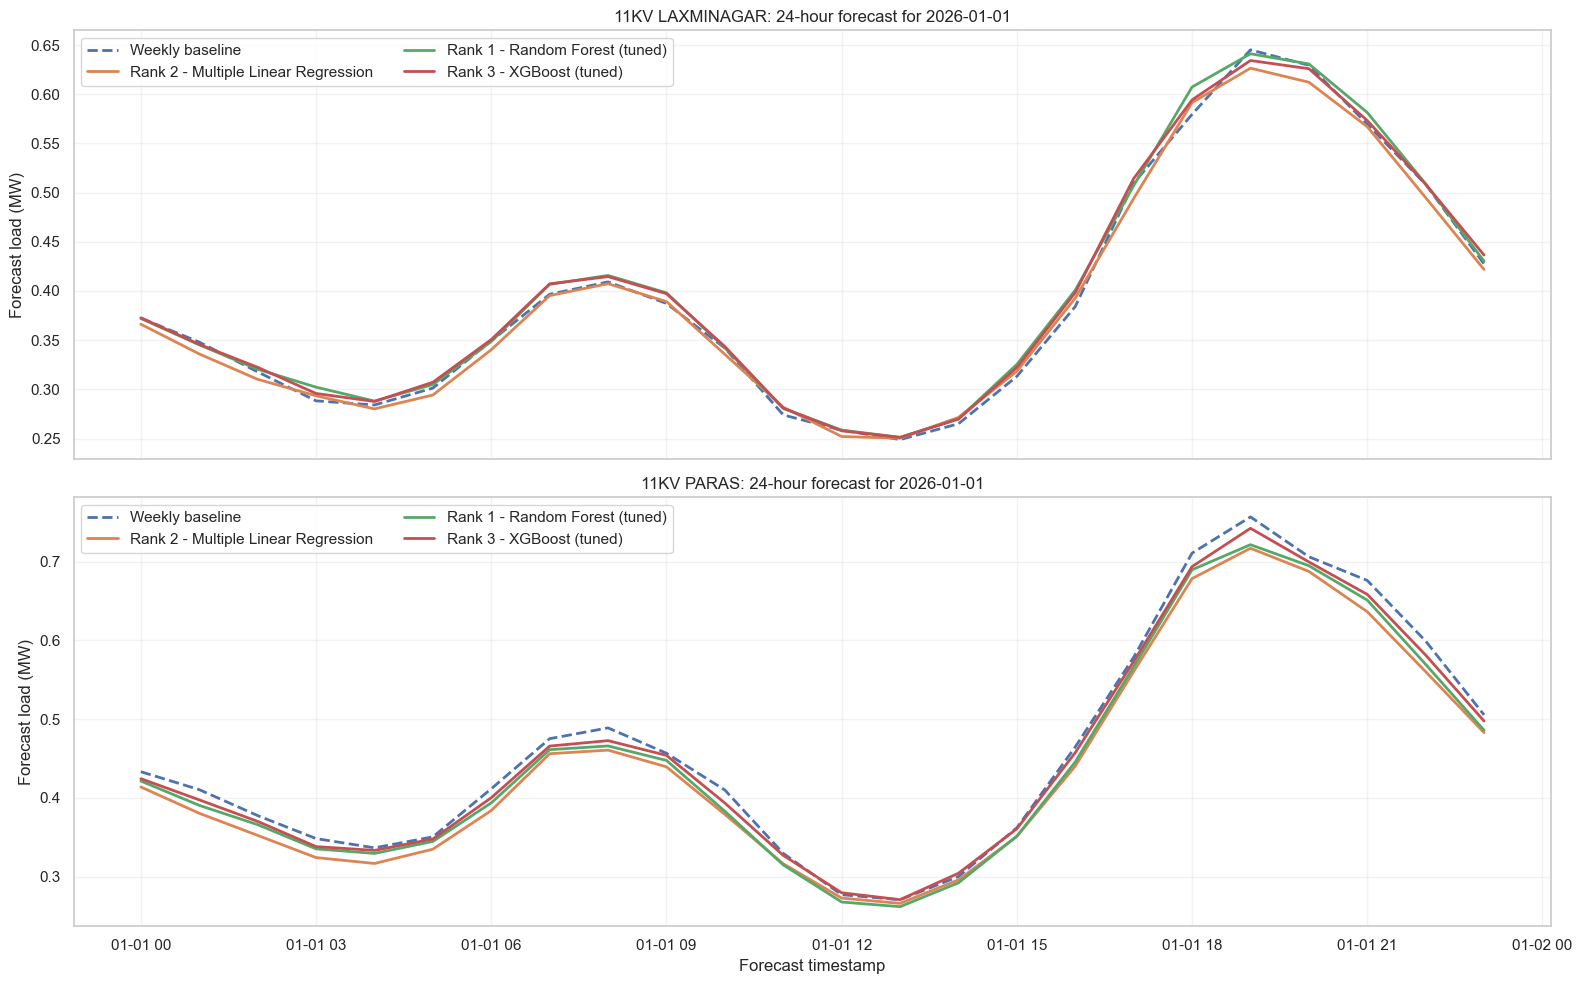

In [117]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for axis, (feeder_name, feeder_rows) in zip(
    axes, forecast_predictions_2026.groupby("Feeder Name")
):
    axis.plot(
        feeder_rows["timestamp"],
        feeder_rows["Same-hour previous week"],
        label="Weekly baseline",
        linestyle="--",
        linewidth=2,
    )
    for model_name in deployable_model_names:
        axis.plot(
            feeder_rows["timestamp"],
            feeder_rows[model_name],
            label=ranked_model_labels[model_name],
            linewidth=2,
        )
    axis.set_title(f"{feeder_name}: 24-hour forecast for {forecast_date.date()}")
    axis.set_ylabel("Forecast load (MW)")
    axis.grid(alpha=0.25)
    axis.legend(ncol=2)

axes[-1].set_xlabel("Forecast timestamp")
plt.tight_layout()
plt.show()

The 1 January 2026 forecast demonstration is complete. Accuracy metrics are intentionally omitted because future observed load is unavailable. The dashboard will present these values as forecasts and retain the separate 2025 test metrics as evidence of historical model performance.